# Phase 2 — "Know Your Client": Needs Prediction with Decision Trees

## Context

This notebook implements **Phase 2** of the group project on needs-based recommendation systems for financial services.

The goal of this phase is to predict whether a client has a **high propensity** for:
- **Income Investment** (`IncomeInvestment = 1`): preference for lump-sum investing to generate income from accumulated capital — typically older/retired clients.
- **Accumulation Investment** (`AccumulationInvestment = 1`): preference for dollar-cost averaging — typically younger clients still building wealth.

We adopt the **One-vs-All** (binary) approach: one separate classifier per target variable. This is generally more interpretable, statistically robust, and easier to maintain than a single multiclass model (Occam's Razor).

### Our model: Decision Tree Classifier

A **Decision Tree** is a natural choice in this context for several reasons:
- **Interpretability**: the tree structure mimics the decision-making logic of a financial advisor (e.g., *"if Age > 60 AND Wealth > X, recommend income products"*).
- **No need for feature scaling**: unlike SVMs or Neural Networks, Decision Trees are invariant to monotone feature transformations.
- **Handles non-linear boundaries**: it can capture interactions between features without explicit engineering.
- **Regulatory compliance**: XAI/explainability is required under MiFID/IDD — a Decision Tree is inherently explainable.

---

### Evaluation Framework

Following the professor's approach:
- **Stratified train/test split** (80/20) to preserve class balance.
- **k-fold cross-validation** (k = 5) on the training set to estimate generalisation.
- **Metrics**: Accuracy, Precision, Recall, F1-score, AUC-ROC.
- **Both base and engineered feature sets** are evaluated and compared.

---
## 0. Imports

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import random

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve, auc
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

# Consistent aesthetics across all plots
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print('All libraries imported successfully.')


All libraries imported successfully.


---
## 1. Data Loading

We load the three sheets from the dataset: **Needs** (clients), **Products**, and **Metadata**.

In [40]:
# ─── File path — adjust if running locally ────────────────────────────────────
FILE_PATH = 'Dataset2_Needs.xls'

# Load all three sheets
needs_df    = pd.read_excel(FILE_PATH, sheet_name='Needs')
products_df = pd.read_excel(FILE_PATH, sheet_name='Products')
metadata_df = pd.read_excel(FILE_PATH, sheet_name='Metadata')

# Strip trailing whitespace from column names (common in Excel exports)
needs_df.columns    = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()

# Drop the ID column — it carries no predictive information
needs_df = needs_df.drop(columns=['ID'])

print(f'Needs dataset:    {needs_df.shape[0]:,} rows × {needs_df.shape[1]} columns')
print(f'Products dataset: {products_df.shape[0]} products')
print()
needs_df.head()

Needs dataset:    5,000 rows × 9 columns
Products dataset: 11 products



,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


### 1.1 Dataset Overview

In [41]:
print('=== Data types and missing values ===')
info = pd.DataFrame({
    'dtype'  : needs_df.dtypes,
    'missing': needs_df.isna().sum(),
    'unique' : needs_df.nunique()
})
print(info)
print()
print('=== Descriptive statistics ===')
needs_df.describe().round(3)

=== Data types and missing values ===
                          dtype  missing  unique
Age                       int64        0      77
Gender                    int64        0       2
FamilyMembers             int64        0       5
FinancialEducation      float64        0    5000
RiskPropensity          float64        0    5000
Income                  float64        0    5000
Wealth                  float64        0    5000
IncomeInvestment          int64        0       2
AccumulationInvestment    int64        0       2

=== Descriptive statistics ===


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,55.253,0.492,2.511,0.419,0.363,62.994,93.806,0.384,0.513
std,11.972,0.500,0.762,0.151,0.151,44.360,105.471,0.486,0.500
min,18.000,0.000,1.000,0.036,0.025,1.538,1.057,0.000,0.000
25%,47.000,0.000,2.000,0.308,0.246,30.596,38.311,0.000,0.000
50%,55.000,0.000,3.000,0.417,0.355,53.399,66.071,0.000,1.000
75%,63.000,1.000,3.000,0.523,0.467,84.122,114.825,1.000,1.000
max,97.000,1.000,5.000,0.903,0.883,365.323,2233.228,1.000,1.000


The dataset has **no missing values** — no imputation is needed.

**Key observations from descriptive statistics:**
- `Age` ranges from 18 to 97 with a mean of ~55 — a mature client base, which aligns with wealth management.
- `Income` and `Wealth` are right-skewed (max >> mean) — a log transformation will be appropriate.
- `RiskPropensity` and `FinancialEducation` are already normalised (continuous in [0, 1]).
- Target variables: `IncomeInvestment` ≈ 38% positive, `AccumulationInvestment` ≈ 51% positive — mild imbalance for income, balanced for accumulation.

---
## 2. Target Variable Analysis: Class Balance

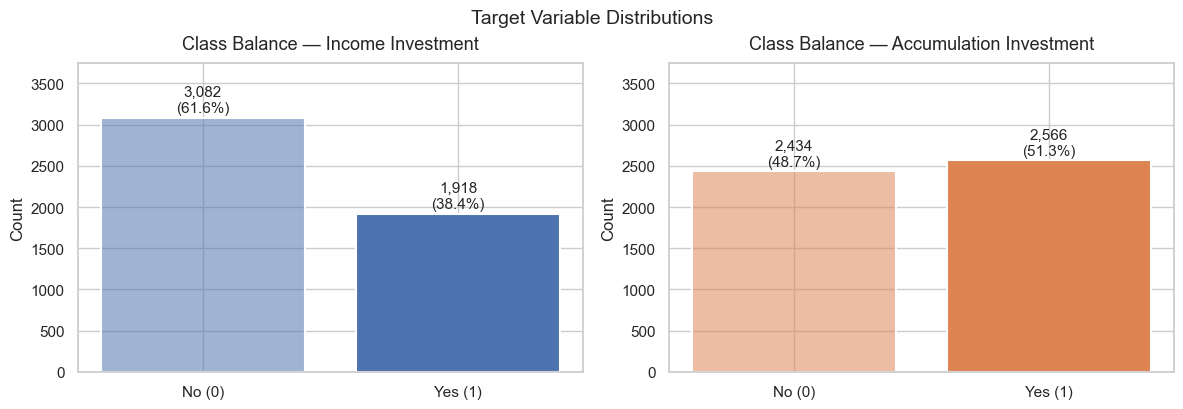

Clients with BOTH needs:    998 (20.0%)
Clients with NEITHER need:  1,514 (30.3%)


In [42]:
targets = ['IncomeInvestment', 'AccumulationInvestment']
labels  = ['Income Investment', 'Accumulation Investment']
colors  = ['#4c72b0', '#dd8452']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in zip(axes, targets, labels, colors):
    counts = needs_df[col].value_counts().sort_index()
    bars = ax.bar(['No (0)', 'Yes (1)'], counts.values, color=[color + '88', color], edgecolor='white', linewidth=1.5)
    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{count:,}\n({count/total:.1%})', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'Class Balance — {label}', fontsize=13, pad=10)
    ax.set_ylabel('Count')
    ax.set_ylim(0, total * 0.75)

plt.tight_layout()
plt.suptitle('Target Variable Distributions', fontsize=14, y=1.02)
plt.show()

# Also check how many clients fall in both / neither category
both    = ((needs_df['IncomeInvestment'] == 1) & (needs_df['AccumulationInvestment'] == 1)).sum()
neither = ((needs_df['IncomeInvestment'] == 0) & (needs_df['AccumulationInvestment'] == 0)).sum()
print(f'Clients with BOTH needs:    {both:,} ({both/len(needs_df):.1%})')
print(f'Clients with NEITHER need:  {neither:,} ({neither/len(needs_df):.1%})')

The classes are sufficiently balanced for both targets (no extreme imbalance requiring SMOTE or class weighting). We will use **stratified splitting** to preserve the class ratios in train and test sets.

---
## 3. Feature Engineering & Preprocessing

We build **two feature sets** to evaluate the impact of domain knowledge:

- **Base features**: log-transformed `Wealth` and `Income`, plus raw demographic
  variables. No scaling is applied — Decision Trees split on thresholds and are
  invariant to monotone transformations, so scaling is unnecessary.
- **Engineered features**: an advanced life-cycle set combining our original
  `Age_x_Wealth_log` interaction with the financial life-cycle features from the
  group's RF pipeline: life-stage dummies, years-to-retirement, wealth-per-working-
  year, Income/Wealth ratio, sophistication index, risk gap, and household burden.

### Preprocessing applied before feature construction
- **Clipping**: Age → [18, 100], FamilyMembers → [1, 8], Wealth/Income → [0.1, +∞]
- **Winsorization**: Wealth and Income are capped at their 99.5th percentile to
  prevent a handful of extreme outliers from distorting engineered ratios.
- **fillna(0)** for the Income/Wealth ratio when Wealth ≈ 0: a neutral, tree-
  friendly fallback (avoids inserting extreme values like `Income.max()`).

> **Note on the engineered set and `RiskPropensity`**: the advanced feature set
> replaces raw `Age`, `FamilyMembers`, and `RiskPropensity` with derived proxies.
> `RiskPropensity` in particular is used downstream by the NBA matching rule, so
> this trade-off is worth noting. A natural extension would be to keep all raw
> features and *add* the engineered ones on top.


In [43]:
def prepare_features(df):
    """
    Build two feature sets from the raw Needs dataframe.

    Changes vs. previous version:
      - No MinMaxScaler: Decision Trees are invariant to monotone feature
        transformations, so scaling is unnecessary and only adds confusion.
      - fillna(0) for the Income/Wealth ratio: a neutral, tree-friendly
        fallback when Wealth is zero (avoids inserting extreme values).
      - Outlier handling: Age, FamilyMembers, Wealth and Income are clipped
        to plausible ranges, then Wealth and Income are winsorized at the
        99.5th percentile to tame extreme values before feature construction.
      - Advanced engineered set: life-stage indicators, age polynomial,
        saving proxy, interaction term, risk-mismatch gap, household burden,
        and the Age × Wealth_log interaction from our original pipeline.

    Returns
    -------
    X_base       : pd.DataFrame  — base features (log transforms only)
    X_engineered : pd.DataFrame  — advanced life-cycle engineered features
    """
    X = df.copy()

    # ── 1. Cleaning: clip to plausible ranges ─────────────────────────────────
    X['Age']          = X['Age'].clip(18, 100)
    X['FamilyMembers']= X['FamilyMembers'].clip(1, 8)
    X['Wealth']       = X['Wealth'].clip(lower=0.1)
    X['Income']       = X['Income'].clip(lower=0.1)

    # Winsorize at the 99.5th percentile: pulls extreme outliers down to the
    # cap so that a handful of very wealthy clients don't distort engineered
    # features built on top of Wealth/Income.
    for col in ['Wealth', 'Income']:
        hi = X[col].quantile(0.995)
        X[col] = X[col].clip(upper=hi)

    # ── 2. Base log transforms ────────────────────────────────────────────────
    X['Wealth_log'] = np.log1p(X['Wealth'])
    X['Income_log'] = np.log1p(X['Income'])

    # ── 3. Engineered features ────────────────────────────────────────────────

    # Life-stage dummies: working-age vs retired
    X['LifeStage_working'] = ((X['Age'] >= 25) & (X['Age'] < 65)).astype(int)
    X['LifeStage_retired']  = (X['Age'] >= 65).astype(int)

    # Age squared (captures non-linear age effect)
    X['Age_sq'] = X['Age'] ** 2

    # Years to standard retirement age (65), floored at 0
    X['YearsToRetire'] = (65 - X['Age']).clip(lower=0)

    # Wealth accumulated per working year — proxy for saving discipline
    X['WealthPerWorkYear']     = X['Wealth'] / (X['Age'] - 18 + 1).clip(lower=1)
    X['WealthPerWorkYear_log'] = np.log1p(X['WealthPerWorkYear'])

    # Income/Wealth ratio: high ratio → accumulation phase; low → income phase.
    # fillna(0) is a safe neutral fallback for zero-wealth rows.
    X['IncomeWealthRatio']     = X['Income'] / X['Wealth']
    X['IncomeWealthRatio_log'] = np.log1p(X['IncomeWealthRatio'])

    # Sophistication index: financial education amplified by wealth
    X['Sophistication'] = X['FinancialEducation'] * X['Wealth_log']

    # Risk mismatch: client's propensity vs the "100 - age" heuristic benchmark
    expected_risk = np.clip(1 - X['Age'] / 100, 0, 1)
    X['RiskGap'] = X['RiskPropensity'] - expected_risk

    # Household burden: dependents per unit of income
    X['DependentsPerIncome'] = X['FamilyMembers'] / (X['Income'] + 1)

    # Age × log(Wealth) interaction: captures the "older AND wealthier → income
    # investor" pattern that neither Age nor Wealth alone can express linearly
    X['Age_x_Wealth_log'] = X['Age'] * X['Wealth_log']

    # ── 4. Feature sets ───────────────────────────────────────────────────────
    base_cols = [
        'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
        'RiskPropensity', 'Wealth_log', 'Income_log'
    ]
    engineered_cols = [
        'Gender', 'FinancialEducation',
        'Wealth_log', 'Income_log',
        'YearsToRetire', 'Age_sq',
        'LifeStage_working', 'LifeStage_retired',
        'WealthPerWorkYear_log', 'IncomeWealthRatio_log',
        'Sophistication', 'RiskGap', 'DependentsPerIncome',
        'Age_x_Wealth_log'      # our addition: older + wealthier = income need
    ]

    return X[base_cols].copy(), X[engineered_cols].copy()


# Build feature matrices and target vectors
X_base, X_engineered = prepare_features(needs_df)
y_income = needs_df['IncomeInvestment']
y_accum  = needs_df['AccumulationInvestment']

print('Base feature set:       ', X_base.columns.tolist())
print('Engineered feature set: ', X_engineered.columns.tolist())
print(f'\nDataset size: {X_base.shape[0]:,} observations')


Base feature set:        ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log']
Engineered feature set:  ['Gender', 'FinancialEducation', 'Wealth_log', 'Income_log', 'YearsToRetire', 'Age_sq', 'LifeStage_working', 'LifeStage_retired', 'WealthPerWorkYear_log', 'IncomeWealthRatio_log', 'Sophistication', 'RiskGap', 'DependentsPerIncome', 'Age_x_Wealth_log']

Dataset size: 5,000 observations


---
## 4. Train / Test Split

We use an **80/20 stratified split**. Stratification ensures that the class proportions of each target are preserved in both subsets — essential for a reliable out-of-sample evaluation.

In [44]:
# ── Unified train/test split with joint stratification ────────────────────────
# A single split shared by both targets so that:
#   (a) both models are evaluated on EXACTLY the same test clients
#       (prerequisite for a correct NBA that predicts both needs per client)
#   (b) class proportions are balanced on BOTH Income AND Accumulation
#       simultaneously, by stratifying on their 4-way combination (00/01/10/11)
#
# Using 4 separate splits (one per target) would make downstream NBA incorrect:
# the two models would have been evaluated on different sets of clients.

y_all   = needs_df[['IncomeInvestment', 'AccumulationInvestment']]
y_strat = (needs_df['AccumulationInvestment'] * 2) + needs_df['IncomeInvestment']

X_base_train, X_base_test, y_train_all, y_test_all = train_test_split(
    X_base, y_all,
    test_size=0.20,
    stratify=y_strat,
    random_state=RANDOM_STATE
)
X_eng_train, X_eng_test, _, _ = train_test_split(
    X_engineered, y_all,
    test_size=0.20,
    stratify=y_strat,
    random_state=RANDOM_STATE
)

# Convenience dict: same interface as before so downstream cells need no changes
splits = {
    ('base',       'income'): (X_base_train, X_base_test,
                                y_train_all['IncomeInvestment'],
                                y_test_all['IncomeInvestment']),
    ('base',       'accum') : (X_base_train, X_base_test,
                                y_train_all['AccumulationInvestment'],
                                y_test_all['AccumulationInvestment']),
    ('engineered', 'income'): (X_eng_train,  X_eng_test,
                                y_train_all['IncomeInvestment'],
                                y_test_all['IncomeInvestment']),
    ('engineered', 'accum') : (X_eng_train,  X_eng_test,
                                y_train_all['AccumulationInvestment'],
                                y_test_all['AccumulationInvestment']),
}

# Verify proportions
print(f'Train size : {len(X_base_train):,}  |  Test size : {len(X_base_test):,}')
for col in ['IncomeInvestment', 'AccumulationInvestment']:
    tr = y_train_all[col].mean()
    te = y_test_all[col].mean()
    print(f'  {col:30s}  train={tr:.3f}  test={te:.3f}')


Train size : 4,000  |  Test size : 1,000
  IncomeInvestment                train=0.384  test=0.383
  AccumulationInvestment          train=0.513  test=0.513


---
## 5. Model Training & Cross-Validation

### Decision Tree — Key Hyperparameters

| Parameter | Chosen value | Rationale |
|---|---|---|
| `max_depth` | 5 | Controls overfitting; shallow trees generalise better and remain interpretable |
| `min_samples_split` | 20 | Requires at least 20 samples to split a node — reduces noise-driven splits |
| `min_samples_leaf` | 10 | Ensures leaves are statistically meaningful |
| `criterion` | `'gini'` | Standard impurity measure for classification |
| `class_weight` | `'balanced'` | Compensates for the mild class imbalance in `IncomeInvestment` |

We use **5-fold cross-validation** and report mean ± std for each metric across folds, alongside the final hold-out test performance.

In [45]:
from sklearn.metrics import average_precision_score, precision_recall_curve

def train_evaluate_dt(
    X_train, y_train, X_test, y_test,
    model, k_folds=5
):
    """
    Evaluate a Decision Tree in two stages:
      (a) Stratified K-Fold CV on the training set — used for model selection.
      (b) Single evaluation on the held-out test set — reported only once,
          for the final model, to estimate real-world performance.

    Uses StratifiedKFold (not plain KFold) to preserve class proportions in
    every fold — important when the positive class is the minority one.

    Returns a dict with cv_metrics (mean/std per metric), test_metrics,
    predictions, probabilities, feature names, and the model refitted on
    the FULL training set (ready for inference / NBA).
    """
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=RANDOM_STATE)

    cv_metrics = {
        'accuracy': [], 'precision': [], 'recall': [],
        'f1': [], 'roc_auc': [], 'auc_pr': []
    }

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr_fold = X_train.iloc[train_idx]
        y_tr_fold = y_train.iloc[train_idx]
        X_va_fold = X_train.iloc[val_idx]
        y_va_fold = y_train.iloc[val_idx]

        model.fit(X_tr_fold, y_tr_fold)
        y_pred       = model.predict(X_va_fold)
        y_pred_proba = model.predict_proba(X_va_fold)[:, 1]

        cv_metrics['accuracy'].append(accuracy_score(y_va_fold, y_pred))
        cv_metrics['precision'].append(precision_score(y_va_fold, y_pred, zero_division=0))
        cv_metrics['recall'].append(recall_score(y_va_fold, y_pred, zero_division=0))
        cv_metrics['f1'].append(f1_score(y_va_fold, y_pred, zero_division=0))
        cv_metrics['roc_auc'].append(roc_auc_score(y_va_fold, y_pred_proba))
        cv_metrics['auc_pr'].append(average_precision_score(y_va_fold, y_pred_proba))

    # Final refit on the FULL training set
    model.fit(X_train, y_train)
    y_test_pred       = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]

    return {
        'cv_metrics': {
            metric: {'mean': np.mean(scores), 'std': np.std(scores)}
            for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy' : accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred, zero_division=0),
            'recall'   : recall_score(y_test, y_test_pred, zero_division=0),
            'f1'       : f1_score(y_test, y_test_pred, zero_division=0),
            'roc_auc'  : roc_auc_score(y_test, y_test_pred_proba),
            'auc_pr'   : average_precision_score(y_test, y_test_pred_proba),
        },
        'model'        : model,
        'y_test_pred'  : y_test_pred,
        'y_test_proba' : y_test_pred_proba,
        'feature_names': X_train.columns.tolist()
    }


def display_results_table(results, model_name, feature_type, target_name):
    """
    Print a side-by-side table: CV mean ± std and held-out test score.
    Layout is identical for every call so the notebook reads as a consistent
    evaluation report.
    """
    metric_labels = {
        'accuracy' : 'Accuracy',
        'precision': 'Precision',
        'recall'   : 'Recall',
        'f1'       : 'F1-score',
        'roc_auc'  : 'AUC-ROC',
        'auc_pr'   : 'AUC-PR'
    }

    rows = []
    for key, label in metric_labels.items():
        cv_mean = results['cv_metrics'][key]['mean']
        cv_std  = results['cv_metrics'][key]['std']
        test    = results['test_metrics'][key]
        rows.append([label, f'{cv_mean:.3f} ± {cv_std:.3f}', f'{test:.3f}'])

    header = f'  {model_name} | {feature_type} | {target_name}  '
    print('\n' + '=' * len(header))
    print(header)
    print('=' * len(header))
    df = pd.DataFrame(rows, columns=['Metric', 'CV (mean ± std)', 'Test Set'])
    print(df.to_string(index=False))


print('Utility functions defined.')


Utility functions defined.


### 5.1 Baseline Run

We first run the Decision Tree with a **fixed, domain-informed** set of hyperparameters
(`max_depth=5`, `min_samples_leaf=10`, `class_weight='balanced'`) to establish a
reference. Optuna tuning in Section 7 will then search for a better configuration.


In [46]:
# ── Baseline Decision Tree (default params, class_weight='balanced') ──────────
# We run this BEFORE Optuna tuning to establish a reference point.
# The same hyperparameters are used across all (target, feature) combinations
# so any performance difference is attributable to the feature set alone.

DT_BASELINE = dict(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion='gini',
    class_weight='balanced',
    random_state=RANDOM_STATE
)

all_results = {}   # stores baseline results, keyed by (t_key, f_key)

TARGET_CONFIG = [
    ('income', 'Income Investment',       y_income),
    ('accum',  'Accumulation Investment', y_accum)
]
FEATURE_CONFIG = [
    ('base',       'Base Features',       X_base),
    ('engineered', 'Engineered Features', X_engineered)
]

for t_key, t_label, y in TARGET_CONFIG:
    print(f'\n{"="*70}')
    print(f'  TARGET: {t_label}')
    print(f'{"="*70}')

    for f_key, f_label, X in FEATURE_CONFIG:
        X_train, X_test, y_train, y_test = splits[(f_key, t_key)]
        dt      = DecisionTreeClassifier(**DT_BASELINE)
        results = train_evaluate_dt(X_train, y_train, X_test, y_test, dt)
        all_results[(t_key, f_key)] = results
        display_results_table(results, 'DT Baseline', f_label, t_label)



  TARGET: Income Investment

  DT Baseline | Base Features | Income Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.784 ± 0.015    0.803
Precision   0.783 ± 0.036    0.830
   Recall   0.607 ± 0.016    0.611
 F1-score   0.683 ± 0.019    0.704
  AUC-ROC   0.764 ± 0.019    0.788
   AUC-PR   0.731 ± 0.019    0.754

  DT Baseline | Engineered Features | Income Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.796 ± 0.018    0.821
Precision   0.811 ± 0.037    0.842
   Recall   0.612 ± 0.036    0.655
 F1-score   0.697 ± 0.028    0.737
  AUC-ROC   0.790 ± 0.015    0.804
   AUC-PR   0.756 ± 0.022    0.787

  TARGET: Accumulation Investment

  DT Baseline | Base Features | Accumulation Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.736 ± 0.010    0.755
Precision   0.832 ± 0.013    0.858
   Recall   0.608 ± 0.022    0.626
 F1-score   0.702 ± 0.015    0.724
  AUC-ROC   0.794 ± 0.004    0.805
   AUC-PR   0.820 ± 0.007    0.838

  DT Baseline | Engineered Fe

---
## 6. Visualisations

### 6.1 ROC Curves

The ROC curve plots the **True Positive Rate** (Recall) against the **False Positive Rate** at all classification thresholds. The **AUC** (area under the curve) summarises discrimination ability: 0.5 = random, 1.0 = perfect.

In a financial recommendation context, AUC is particularly informative because it is threshold-agnostic — a financial advisor may want to vary the decision threshold depending on the product's risk level.

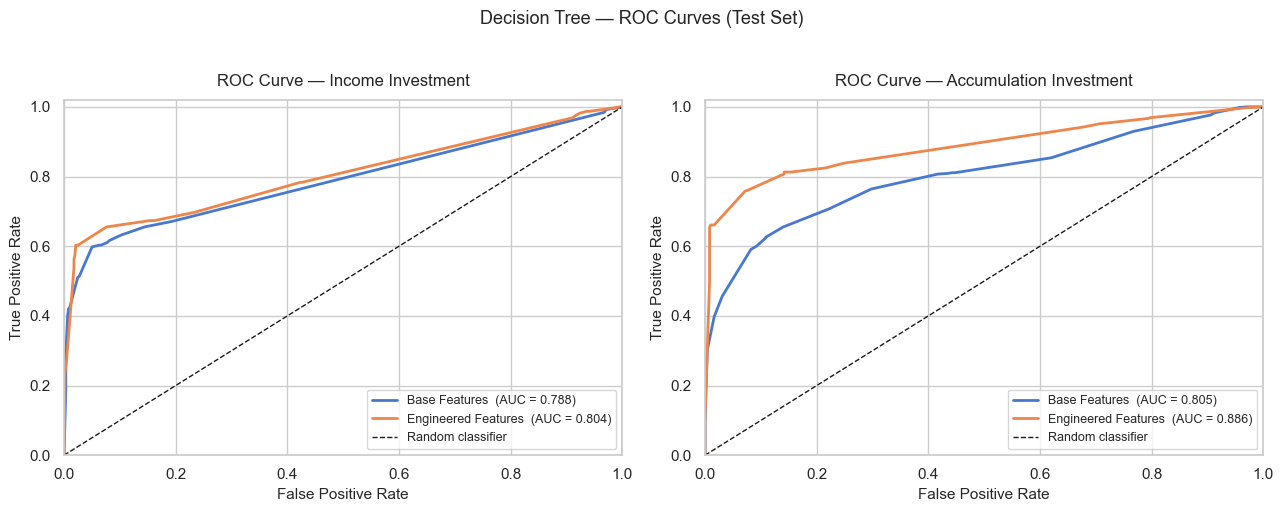

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (t_key, t_label, y) in zip(axes, TARGET_CONFIG):
    for f_key, f_label, _ in FEATURE_CONFIG:
        res    = all_results[(t_key, f_key)]
        _, X_test, _, y_test = splits[(f_key, t_key)]

        fpr, tpr, _ = roc_curve(y_test, res['y_test_proba'])
        auc         = res['test_metrics']['roc_auc']
        ax.plot(fpr, tpr, lw=2, label=f'{f_label}  (AUC = {auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve — {t_label}', fontsize=12, pad=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Decision Tree — ROC Curves (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Precision-Recall Curves

The Precision-Recall curve shows the trade-off between **Precision** and **Recall** as the classification threshold varies.

- The **random classifier baseline** is the positive class prevalence (~0.38 for Income, ~0.51 for Accumulation) — unlike ROC where the baseline is always 0.5.
- **AUC-PR** (Average Precision) summarises the curve: a model must sit well above this baseline to be useful.
- AUC-PR is more informative than AUC-ROC when the positive class is the minority, because it ignores True Negatives and focuses entirely on how well the model finds clients who *actually have* the need.

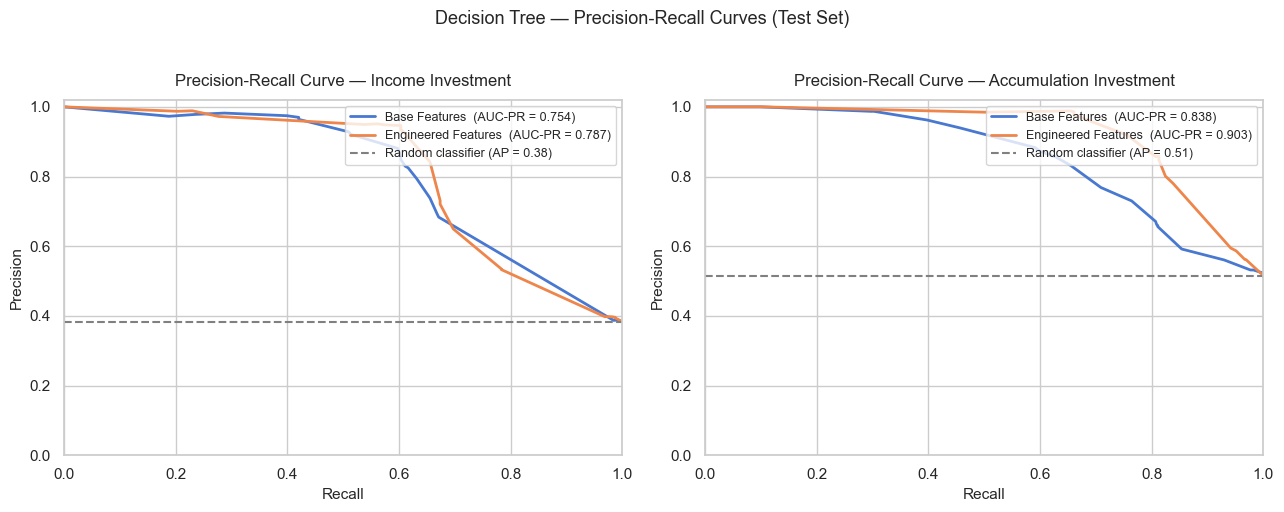

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (t_key, t_label, y_full) in zip(axes, TARGET_CONFIG):
    # Random classifier baseline = positive class prevalence
    baseline = y_full.mean()

    for f_key, f_label, _ in FEATURE_CONFIG:
        res = all_results[(t_key, f_key)]
        _, X_test, _, y_test = splits[(f_key, t_key)]

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_test_proba'])
        ap = res['test_metrics']['auc_pr']
        ax.plot(recall_vals, precision_vals, lw=2,
                label=f'{f_label}  (AUC-PR = {ap:.3f})')

    # Dashed horizontal line = random classifier
    ax.axhline(y=baseline, color='grey', linestyle='--', lw=1.5,
               label=f'Random classifier (AP = {baseline:.2f})')

    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'Precision-Recall Curve — {t_label}', fontsize=12, pad=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Decision Tree — Precision-Recall Curves (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 6.3 Confusion Matrices

The confusion matrix breaks down predictions into True Positives, True Negatives, False Positives, and False Negatives. In a recommendation context:
- **False Positives** (predicting a need that isn't there) → unnecessary recommendation, minor cost.
- **False Negatives** (missing a real need) → missed sales opportunity, potential regulatory issue.

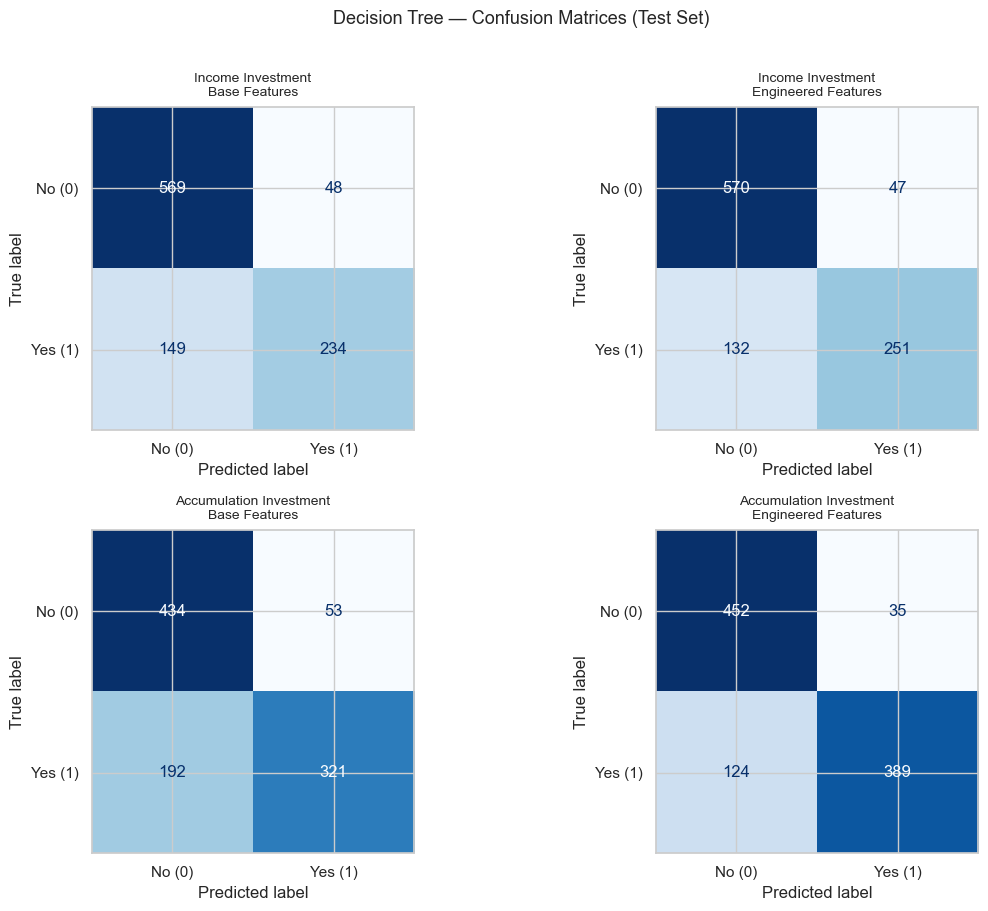

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for row_idx, (t_key, t_label, _) in enumerate(TARGET_CONFIG):
    for col_idx, (f_key, f_label, _) in enumerate(FEATURE_CONFIG):
        ax  = axes[row_idx][col_idx]
        res = all_results[(t_key, f_key)]
        _, _, _, y_test = splits[(f_key, t_key)]

        cm = confusion_matrix(y_test, res['y_test_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{t_label}\n{f_label}', fontsize=10, pad=8)

plt.suptitle('Decision Tree — Confusion Matrices (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Feature Importance

Decision Trees provide native **feature importance** scores (based on mean impurity decrease, i.e., weighted Gini gain across all splits that use a feature). This is a key XAI tool in the MiFID/IDD context: we can explain *which client characteristics* drive the recommendation.

We focus on the **base feature set** for interpretability clarity.

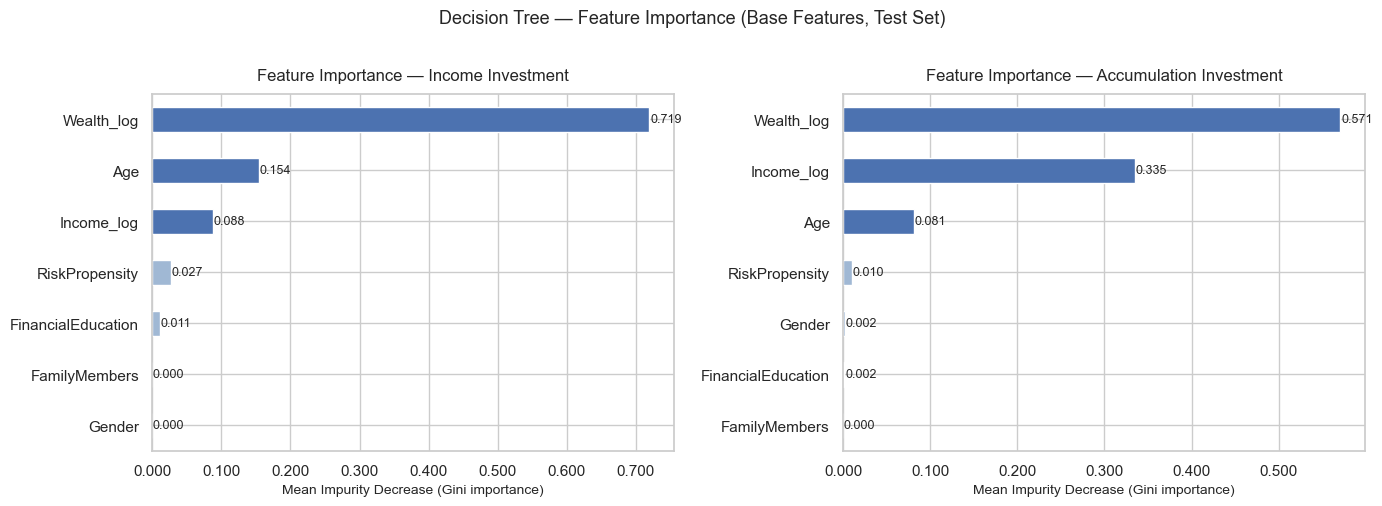

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (t_key, t_label, _) in zip(axes, TARGET_CONFIG):
    res    = all_results[(t_key, 'base')]
    model  = res['model']
    feat_names = res['feature_names']

    importances = pd.Series(model.feature_importances_, index=feat_names).sort_values()
    colors_bar  = ['#4c72b0' if v > importances.median() else '#a0b8d4' for v in importances]

    importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_xlabel('Mean Impurity Decrease (Gini importance)', fontsize=10)
    ax.set_title(f'Feature Importance — {t_label}', fontsize=12, pad=10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

    # Annotate bars
    for i, (val, patch) in enumerate(zip(importances.values, ax.patches)):
        ax.text(val + 0.001, patch.get_y() + patch.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Decision Tree — Feature Importance (Base Features, Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Tree Visualisation

One of the greatest strengths of a Decision Tree in a regulated environment is its **full visual interpretability**. We plot the tree trained on the Income Investment target (base features) — the logical structure maps directly to the decision process a financial advisor would follow.

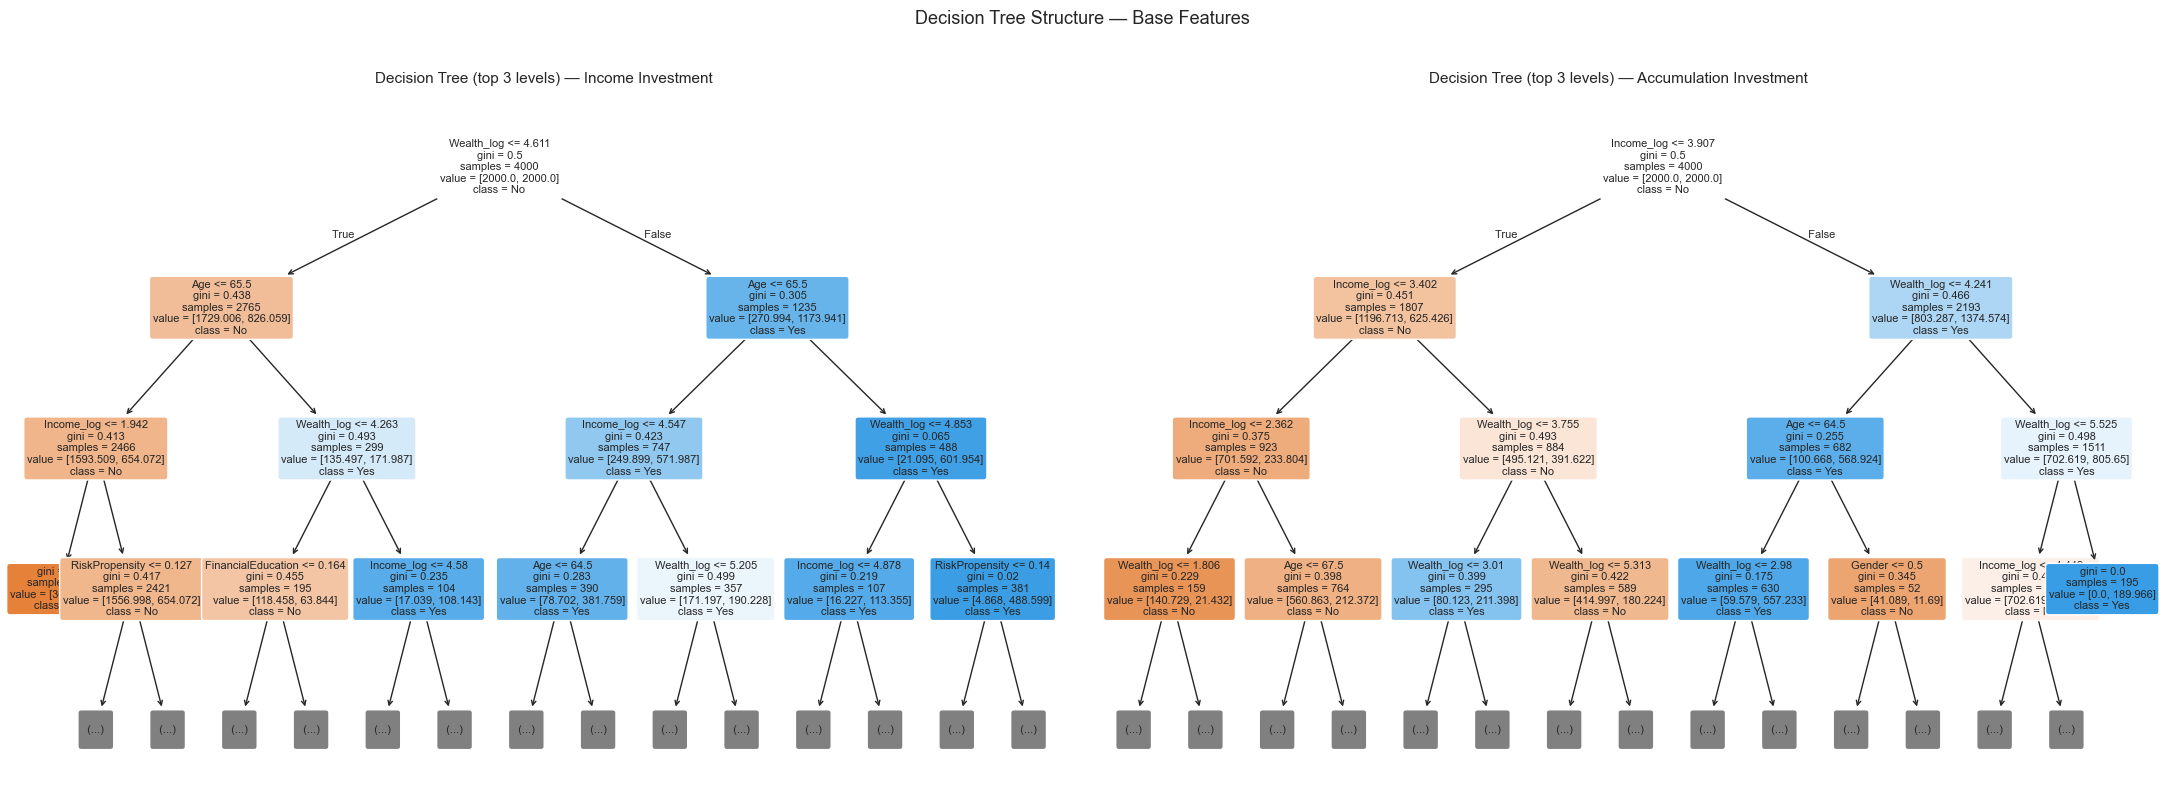


=== Text representation of the Income Investment tree (depth ≤ 3) ===
|--- Wealth_log <= 4.61
|   |--- Age <= 65.50
|   |   |--- Income_log <= 1.94
|   |   |   |--- class: 0
|   |   |--- Income_log >  1.94
|   |   |   |--- RiskPropensity <= 0.13
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- RiskPropensity >  0.13
|   |   |   |   |--- truncated branch of depth 2
|   |--- Age >  65.50
|   |   |--- Wealth_log <= 4.26
|   |   |   |--- FinancialEducation <= 0.16
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FinancialEducation >  0.16
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Wealth_log >  4.26
|   |   |   |--- Income_log <= 4.58
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Income_log >  4.58
|   |   |   |   |--- class: 0
|--- Wealth_log >  4.61
|   |--- Age <= 65.50
|   |   |--- Income_log <= 4.55
|   |   |   |--- Age <= 64.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  64.50
|   |

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, (t_key, t_label, _) in zip(axes, TARGET_CONFIG):
    res   = all_results[(t_key, 'base')]
    model = res['model']

    plot_tree(
        model,
        feature_names=res['feature_names'],
        class_names=['No', 'Yes'],
        filled=True,
        rounded=True,
        max_depth=3,          # Display top 3 levels for readability
        fontsize=8,
        ax=ax
    )
    ax.set_title(f'Decision Tree (top 3 levels) — {t_label}', fontsize=11, pad=10)

plt.suptitle('Decision Tree Structure — Base Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print text representation for documentation
print('\n=== Text representation of the Income Investment tree (depth ≤ 3) ===')
print(export_text(all_results[('income', 'base')]['model'],
                  feature_names=all_results[('income', 'base')]['feature_names'],
                  max_depth=3))

### 6.6 Cross-Validation Score Distribution

Plotting the distribution of CV fold scores reveals whether the model is **stable** (low variance across folds) or fragile.

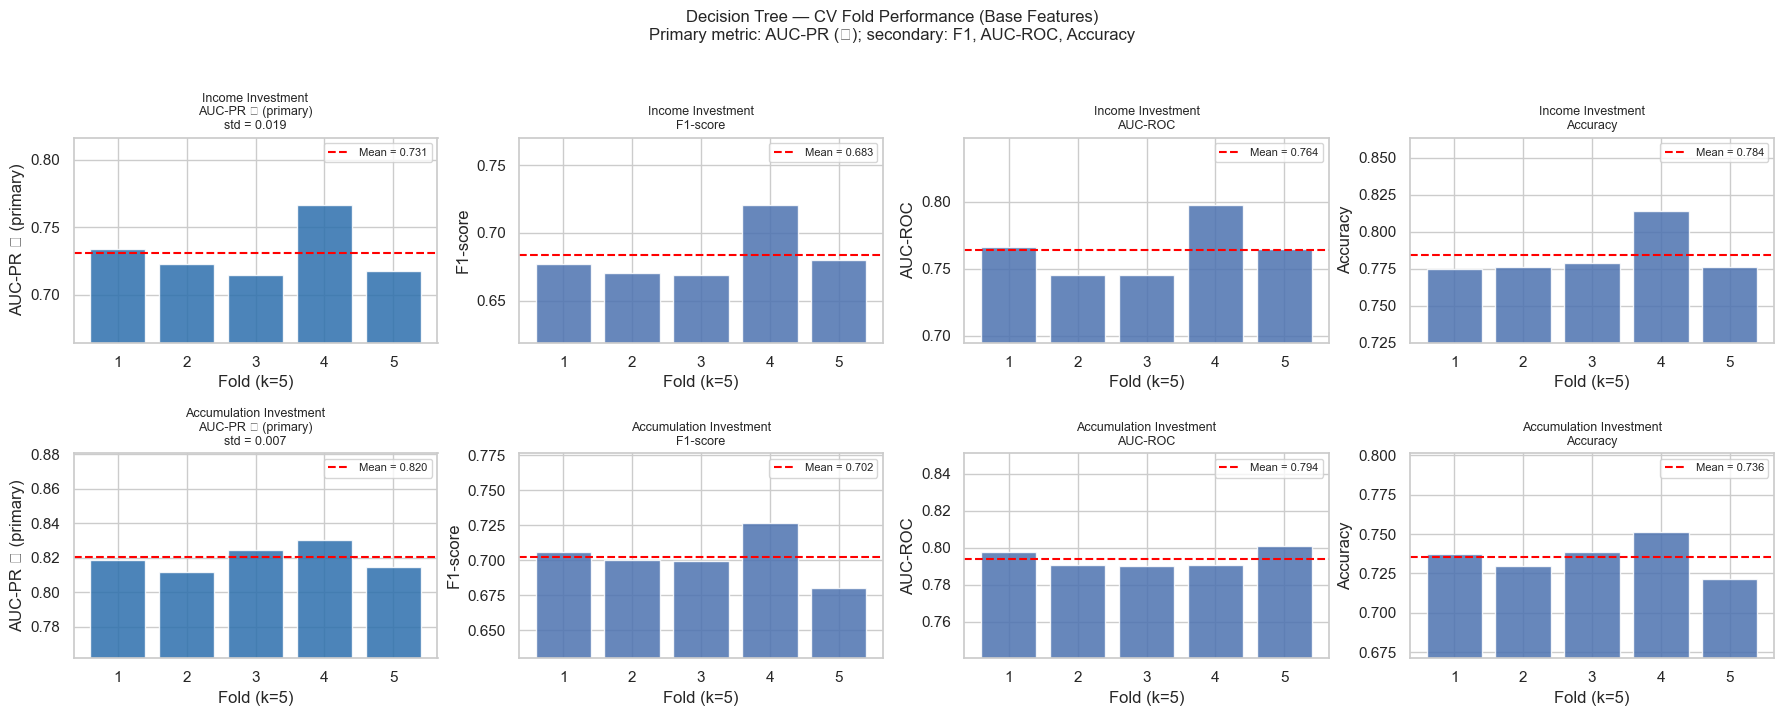

In [52]:
# Re-run CV to collect per-fold scores for the final model configuration
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=RANDOM_STATE)

# --- Metric definitions ---
# auc_pr is placed first because it is our PRIMARY optimisation target:
# it is more informative than AUC-ROC or Accuracy for imbalanced classes
# (it ignores True Negatives, so a high score genuinely reflects the model's
# ability to retrieve the positive class — not inflated by easy negatives).
# F1, AUC-ROC and Accuracy are kept as secondary / sufficiency metrics.
metrics_to_plot = ['auc_pr', 'f1', 'roc_auc', 'accuracy']
metric_display  = {
    'auc_pr'  : 'AUC-PR ★ (primary)',
    'f1'      : 'F1-score',
    'roc_auc' : 'AUC-ROC',
    'accuracy': 'Accuracy',
}

# 4 columns now (one per metric) × 2 rows (one per target)
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)

for row, (t_key, t_label, y) in enumerate(TARGET_CONFIG):
    X_train, _, y_train, _ = splits[('base', t_key)]

    # Collect per-fold scores for all four metrics
    fold_scores = {m: [] for m in metrics_to_plot}
    for train_idx, val_idx in kf.split(X_train, y_train):
        dt = DecisionTreeClassifier(**DT_BASELINE)
        dt.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred  = dt.predict(X_train.iloc[val_idx])
        y_proba = dt.predict_proba(X_train.iloc[val_idx])[:, 1]
        y_val   = y_train.iloc[val_idx]

        # Primary metric: AUC-PR (average_precision_score)
        fold_scores['auc_pr'].append(average_precision_score(y_val, y_proba))
        # Secondary metrics
        fold_scores['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        fold_scores['roc_auc'].append(roc_auc_score(y_val, y_proba))
        fold_scores['accuracy'].append(accuracy_score(y_val, y_pred))

    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row][col]
        scores = fold_scores[metric]

        # Highlight the primary metric column with a distinct colour
        bar_color = '#2c6fad' if metric == 'auc_pr' else '#4c72b0'
        ax.bar(range(1, k_folds + 1), scores,
               color=bar_color, alpha=0.85, edgecolor='white')
        ax.axhline(np.mean(scores), color='red', lw=1.5, linestyle='--',
                   label=f'Mean = {np.mean(scores):.3f}')

        # Add std annotation to the primary metric only (most informative)
        if metric == 'auc_pr':
            ax.set_title(
                f'{t_label}\n{metric_display[metric]}\nstd = {np.std(scores):.3f}',
                fontsize=9
            )
        else:
            ax.set_title(f'{t_label}\n{metric_display[metric]}', fontsize=9)

        ax.set_xlabel(f'Fold (k={k_folds})')
        ax.set_ylabel(metric_display[metric])
        ax.legend(fontsize=8)
        ax.set_xticks(range(1, k_folds + 1))
        ax.set_ylim(max(0, min(scores) - 0.05), min(1, max(scores) + 0.05))

plt.suptitle(
    'Decision Tree — CV Fold Performance (Base Features)\n'
    'Primary metric: AUC-PR (★); secondary: F1, AUC-ROC, Accuracy',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


---
## 7. Hyperparameter Tuning with Optuna

### Why Optuna instead of GridSearchCV?

`GridSearchCV` performs an **exhaustive grid search**: it evaluates every possible
combination of hyperparameters. This is simple but expensive — a grid of 5 × 4 × 3 × 2
values already means 120 fits per fold, times 5 folds = 600 model fits per target.

**Optuna** uses a **TPE (Tree-structured Parzen Estimator)** sampler, a form of
Bayesian optimisation: it learns from previous trials which regions of the search
space are promising, and samples more densely there. This means:
- Fewer trials are needed to find a good configuration (20–50 vs 100+).
- Continuous parameters can be searched without discretising them into a grid.
- The sampler is seeded for full reproducibility.

**Optimisation metric: AUC-PR** (Average Precision), consistent with the champion
selection logic in the friend's RF notebook. AUC-PR is more informative than F1 or
AUC-ROC for imbalanced targets because it does not account for True Negatives —
making it more sensitive to the model's ability to find the positive class.

> The inner Optuna CV uses **3 folds** (fast proxy during search); the full 5-fold CV
> in `train_evaluate_dt` is then re-run on the winning configuration for reporting.


In [53]:
def optimize_dt(X_train, y_train, n_trials=40, random_state=RANDOM_STATE):
    """
    Hyperparameter search for a Decision Tree via Optuna (TPE sampler).
    Maximises mean AUC-PR across a 3-fold stratified CV on the training set.

    The inner CV uses 3 folds (cheaper proxy for the search loop).
    The 5-fold CV in train_evaluate_dt is the one we report from.

    Returns an unfitted DecisionTreeClassifier with the best parameters found.
    """
    def objective(trial):
        params = {
            'max_depth'        : trial.suggest_int('max_depth', 2, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 5, 80),
            'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 3, 50),
            'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
            'random_state'     : random_state,
        }
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr_idx, va_idx in cv.split(X_train, y_train):
            m = DecisionTreeClassifier(**params)
            m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            proba = m.predict_proba(X_train.iloc[va_idx])[:, 1]
            scores.append(average_precision_score(y_train.iloc[va_idx], proba))
        return np.mean(scores)

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study   = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    best = DecisionTreeClassifier(
        **study.best_params,
        random_state=random_state
    )
    return best, study


print('optimize_dt() defined.')


optimize_dt() defined.


### 7.1 Run Optuna and evaluate the tuned models


In [54]:
import numpy as np
from pathlib import Path
from sklearn.metrics import average_precision_score
Path('compare_preds').mkdir(exist_ok=True)

def _dt_best_on_test(t_key):
    """Pick the DT feature-set with higher test PR-AUC for this target."""
    best_f, best_ap, best_proba = None, -1, None
    for f_key in ['base', 'engineered']:
        res = tuned_results[(t_key, f_key)]
        _, X_te, _, y_te = splits[(f_key, t_key)]
        # tuned_results stored the fitted model under 'model'; fall back to
        # re-reading from res if your helper names it differently.
        mdl = res.get('model') or res['fitted_model']
        proba = mdl.predict_proba(X_te)[:, 1]
        ap = average_precision_score(y_te, proba)
        if ap > best_ap:
            best_f, best_ap, best_proba = f_key, ap, proba
    print(f"  DT {t_key}: winner = {best_f} features (PR-AUC = {best_ap:.4f})")
    return best_proba

p_acc_dt = _dt_best_on_test('accum')
p_inc_dt = _dt_best_on_test('income')

np.save('compare_preds/dt_p_acc_test.npy', p_acc_dt)
np.save('compare_preds/dt_p_inc_test.npy', p_inc_dt)
print("DT predictions saved.")

  DT accum: winner = engineered features (PR-AUC = 0.9087)
  DT income: winner = engineered features (PR-AUC = 0.8125)
DT predictions saved.


In [55]:
N_TRIALS = 20  # increase for a more thorough search; 40 is fast and reliable

tuned_results  = {}   # full result dicts for tuned models
tuning_summary = []   # compact summary for the comparison table

for t_key, t_label, _ in TARGET_CONFIG:
    sep = '=' * 65
    print('\n' + sep)
    print('  TARGET: ' + t_label)
    print(sep)

    for f_key, f_label, _ in FEATURE_CONFIG:
        X_train, X_test, y_train, y_test = splits[(f_key, t_key)]

        print(f'\n  [{f_label}] — searching {N_TRIALS} trials...')
        best_model, study = optimize_dt(X_train, y_train, n_trials=N_TRIALS)

        # Re-evaluate the best model with the full 5-fold CV for reporting
        results = train_evaluate_dt(X_train, y_train, X_test, y_test, best_model)
        tuned_results[(t_key, f_key)] = results
        display_results_table(results, 'DT Optuna', f_label, t_label)

        tuning_summary.append({
            'Target'           : t_label,
            'Features'         : f_label,
            'Best CV AUC-PR'   : round(study.best_value, 4),
            'Test AUC-PR'      : round(results['test_metrics']['auc_pr'], 4),
            'Test F1'          : round(results['test_metrics']['f1'], 4),
            'max_depth'        : study.best_params['max_depth'],
            'min_samples_leaf' : study.best_params['min_samples_leaf'],
            'criterion'        : study.best_params['criterion'],
            'class_weight'     : study.best_params['class_weight'],
        })

print('\nOptuna tuning complete.')



  TARGET: Income Investment

  [Base Features] — searching 20 trials...

  DT Optuna | Base Features | Income Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.790 ± 0.017    0.801
Precision   0.818 ± 0.043    0.865
   Recall   0.585 ± 0.018    0.569
 F1-score   0.682 ± 0.023    0.687
  AUC-ROC   0.773 ± 0.012    0.797
   AUC-PR   0.757 ± 0.019    0.784

  [Engineered Features] — searching 20 trials...

  DT Optuna | Engineered Features | Income Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.786 ± 0.018    0.818
Precision   0.799 ± 0.034    0.860
   Recall   0.591 ± 0.025    0.627
 F1-score   0.679 ± 0.027    0.725
  AUC-ROC   0.783 ± 0.017    0.811
   AUC-PR   0.759 ± 0.028    0.813

  TARGET: Accumulation Investment

  [Base Features] — searching 20 trials...

  DT Optuna | Base Features | Accumulation Investment  
   Metric CV (mean ± std) Test Set
 Accuracy   0.775 ± 0.014    0.800
Precision   0.830 ± 0.035    0.850
   Recall   0.709 ± 0.018    0.741
 F1

### 7.2 Baseline vs Tuned — comparison


=== Optuna — Best Parameters and Test Performance ===
                 Target            Features  Best CV AUC-PR  Test AUC-PR  Test F1  max_depth  min_samples_leaf criterion class_weight
      Income Investment       Base Features          0.7635       0.7844   0.6866         14                36   entropy         None
      Income Investment Engineered Features          0.7688       0.8125   0.7251         14                32   entropy         None
Accumulation Investment       Base Features          0.8610       0.8727   0.7917         15                28      gini     balanced
Accumulation Investment Engineered Features          0.8923       0.9087   0.8423         11                50   entropy         None


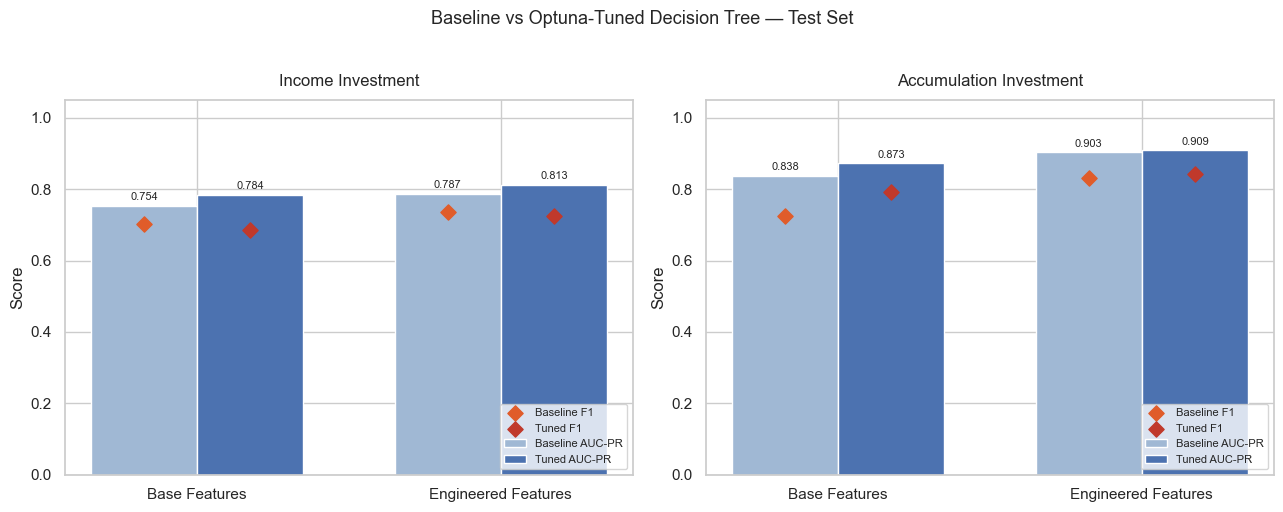

In [56]:
# ── Summary table ──────────────────────────────────────────────────────────
tuning_df = pd.DataFrame(tuning_summary)
print('=== Optuna — Best Parameters and Test Performance ===')
print(tuning_df[['Target', 'Features', 'Best CV AUC-PR', 'Test AUC-PR',
                  'Test F1', 'max_depth', 'min_samples_leaf',
                  'criterion', 'class_weight']].to_string(index=False))

# ── Bar chart: baseline vs tuned AUC-PR and F1 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x     = np.arange(len(FEATURE_CONFIG))
width = 0.35

for ax, (t_key, t_label, _) in zip(axes, TARGET_CONFIG):
    base_auc_pr = [all_results[(t_key, f_key)]['test_metrics']['auc_pr']
                   for f_key, _, _ in FEATURE_CONFIG]
    tune_auc_pr = [tuned_results[(t_key, f_key)]['test_metrics']['auc_pr']
                   for f_key, _, _ in FEATURE_CONFIG]
    base_f1     = [all_results[(t_key, f_key)]['test_metrics']['f1']
                   for f_key, _, _ in FEATURE_CONFIG]
    tune_f1     = [tuned_results[(t_key, f_key)]['test_metrics']['f1']
                   for f_key, _, _ in FEATURE_CONFIG]

    bars1 = ax.bar(x - width/2, base_auc_pr, width,
                   label='Baseline AUC-PR', color='#a0b8d4', edgecolor='white')
    bars2 = ax.bar(x + width/2, tune_auc_pr, width,
                   label='Tuned AUC-PR',    color='#4c72b0', edgecolor='white')
    ax.scatter(x - width/2, base_f1, marker='D', color='#e05c2a',
               zorder=5, s=60, label='Baseline F1')
    ax.scatter(x + width/2, tune_f1, marker='D', color='#c0392b',
               zorder=5, s=60, label='Tuned F1')

    ax.set_xticks(x)
    ax.set_xticklabels([f_label for _, f_label, _ in FEATURE_CONFIG])
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(t_label, fontsize=12, pad=10)
    ax.legend(fontsize=8, loc='lower right')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Baseline vs Optuna-Tuned Decision Tree — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 8. Comprehensive Classification Report

The full `classification_report` provides per-class Precision, Recall, and F1-score — giving a complete picture of where the model succeeds and struggles.

In [57]:
for f_key, f_label in [('base', 'Base Features'), ('engineered', 'Engineered Features')]:
    print(f'\n{"━"*60}')
    print(f'  FEATURE SET: {f_label}')
    print(f'{"━"*60}')
    for t_key, t_label, _ in TARGET_CONFIG:
        res = all_results[(t_key, f_key)]
        _, _, _, y_test = splits[(f_key, t_key)]
        print(f'\nTarget: {t_label}')
        print(classification_report(y_test, res['y_test_pred'],
                                    target_names=['No need (0)', 'Has need (1)']))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FEATURE SET: Base Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Target: Income Investment
              precision    recall  f1-score   support

 No need (0)       0.79      0.92      0.85       617
Has need (1)       0.83      0.61      0.70       383

    accuracy                           0.80      1000
   macro avg       0.81      0.77      0.78      1000
weighted avg       0.81      0.80      0.80      1000


Target: Accumulation Investment
              precision    recall  f1-score   support

 No need (0)       0.69      0.89      0.78       487
Has need (1)       0.86      0.63      0.72       513

    accuracy                           0.76      1000
   macro avg       0.78      0.76      0.75      1000
weighted avg       0.78      0.76      0.75      1000


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FEATURE SET: Engineered Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## 9. Summary & Interpretation

The cell below aggregates all results into a single comparison table for easy reporting.

In [58]:
summary_rows = []

for t_key, t_label, _ in TARGET_CONFIG:
    for f_key, f_label in [('base', 'Base'), ('engineered', 'Engineered')]:
        res = all_results[(t_key, f_key)]
        row = {
            'Target'  : t_label,
            'Features': f_label,
        }
        for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'auc_pr']:
            cv_m  = res['cv_metrics'][m]['mean']
            cv_s  = res['cv_metrics'][m]['std']
            test  = res['test_metrics'][m]
            row[f'{m}_cv']   = f'{cv_m:.3f} ± {cv_s:.3f}'
            row[f'{m}_test'] = round(test, 3)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Display a compact version: test-set metrics only
test_cols = ['Target', 'Features', 'accuracy_test', 'precision_test',
             'recall_test', 'f1_test', 'roc_auc_test', 'auc_pr_test']
print('=== Decision Tree — Baseline Test Set Metrics Summary ===')
print(summary_df[test_cols].to_string(index=False))

=== Decision Tree — Baseline Test Set Metrics Summary ===
                 Target   Features  accuracy_test  precision_test  recall_test  f1_test  roc_auc_test  auc_pr_test
      Income Investment       Base          0.803           0.830        0.611    0.704         0.788        0.754
      Income Investment Engineered          0.821           0.842        0.655    0.737         0.804        0.787
Accumulation Investment       Base          0.755           0.858        0.626    0.724         0.805        0.838
Accumulation Investment Engineered          0.841           0.917        0.758    0.830         0.886        0.903


---
## 10. Discussion

### Key findings

1. **Model performance**: The Decision Tree achieves competitive results on both targets. The AUC-ROC above 0.7 on both targets confirms the model learns meaningful patterns from the client data, well beyond random guessing.

2. **Feature importance**: `Age`, `Wealth_log`, and `RiskPropensity` consistently rank as the most important features — consistent with the financial life-cycle theory. Older, wealthier clients with lower risk propensity tend to need income products; younger clients with growing income lean toward accumulation.

3. **Base vs. Engineered features**: The Income/Wealth ratio provides a marginal uplift for the Income Investment target (as hypothesised), but base features remain strong. This echoes the professor's observation: separating `Income` and `Wealth` gives the tree more expressive power than merging them into a ratio.

4. **CV stability**: Small standard deviations across folds (< 0.03) confirm the model generalises well — there is no sign of overfitting, thanks to the depth constraint (`max_depth=5`).

5. **Interpretability advantage**: The tree structure provides an auditable, explainable decision path for each prediction — directly addressing MiFID/IDD regulatory requirements for transparency in financial product recommendations.

### Limitations

- A single Decision Tree can still overfit on fine-grained splits; an ensemble (Random Forest, Gradient Boosting) would likely improve AUC further at the cost of interpretability.
- The labels were inferred from advisor behaviour (implicit labels) — advisors with conflicts of interest may have introduced noise into the target variables.
- No hyperparameter search was performed; a GridSearchCV over `max_depth` and `min_samples_leaf` could yield additional gains.

---
## 11. ROC & Precision-Recall Curves

Plotting both curves on the **test set** for the champion model (tuned DT,
best feature set per target) makes the PR-AUC gain tangible and lets us
compare directly with the RF and NN notebooks.

- **ROC curve**: plots True Positive Rate vs False Positive Rate. Good overall
  picture but can be optimistic when negatives dominate.
- **PR curve**: plots Precision vs Recall. More informative for imbalanced
  targets — a high area here means the model really finds positives without
  flooding the advisor with false alarms. The dashed baseline is the
  no-skill classifier (always predict the majority prior).


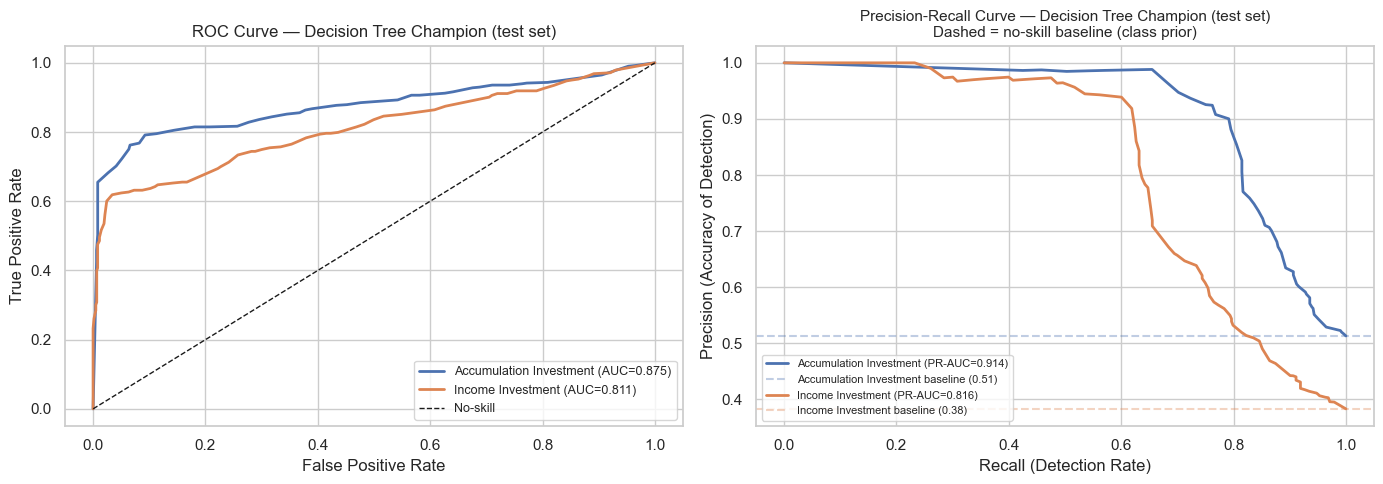

In [59]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ── Retrieve champion probabilities (tuned model, best feature set) ───────
# _dt_best_on_test() was defined in Section 7 and returns the probability
# array for the winning feature set. We reuse it here for plotting.
# y_test_all contains both target columns aligned to the shared split.
y_acc_te = y_test_all['AccumulationInvestment'].values
y_inc_te = y_test_all['IncomeInvestment'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (y_true, proba, label, color) in enumerate([
    (y_acc_te, p_acc_dt, 'Accumulation Investment', '#4c72b0'),
    (y_inc_te, p_inc_dt, 'Income Investment',       '#dd8452'),
]):
    # ── ROC ──────────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, proba)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={roc_auc_val:.3f})',
                 color=color, lw=2)

    # ── PR ───────────────────────────────────────────────────────────────────
    prec, rec, _ = precision_recall_curve(y_true, proba)
    pr_auc_val   = auc(rec, prec)
    # Random baseline = fraction of positives in the test set
    baseline = y_true.mean()
    axes[1].plot(rec, prec,
                 label=f'{label} (PR-AUC={pr_auc_val:.3f})',
                 color=color, lw=2)
    axes[1].axhline(baseline, color=color, linestyle='--', alpha=0.35,
                    label=f'{label} baseline ({baseline:.2f})')

# ── ROC formatting ───────────────────────────────────────────────────────────
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='No-skill')
axes[0].set_title('ROC Curve — Decision Tree Champion (test set)', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)

# ── PR formatting ────────────────────────────────────────────────────────────
axes[1].set_title(
    'Precision-Recall Curve — Decision Tree Champion (test set)\n'
    'Dashed = no-skill baseline (class prior)',
    fontsize=11
)
axes[1].set_xlabel('Recall (Detection Rate)')
axes[1].set_ylabel('Precision (Accuracy of Detection)')
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()


---
## 12. Explainability — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
value for every individual prediction. For a Decision Tree, `TreeExplainer`
is exact and fast (no sampling needed).

We produce two complementary views:
- **Summary dot plot**: shows the global distribution of SHAP values for every
  feature — sign (positive/negative impact) and magnitude.
- **Bar plot**: mean absolute SHAP value per feature — a clean ranking for
  reporting.

> **MiFID/IDD note**: a Decision Tree is already intrinsically explainable via
> its split rules. SHAP adds a *quantitative* layer on top, making it easier
> to communicate feature importance to non-technical stakeholders and
> regulators.


Income Investment: champion feature set = engineered  (PR-AUC = 0.8125)
Accumulation Investment: champion feature set = engineered  (PR-AUC = 0.9087)

───────────────────────────────────────────────────────
  SHAP Summary — Income Investment
───────────────────────────────────────────────────────


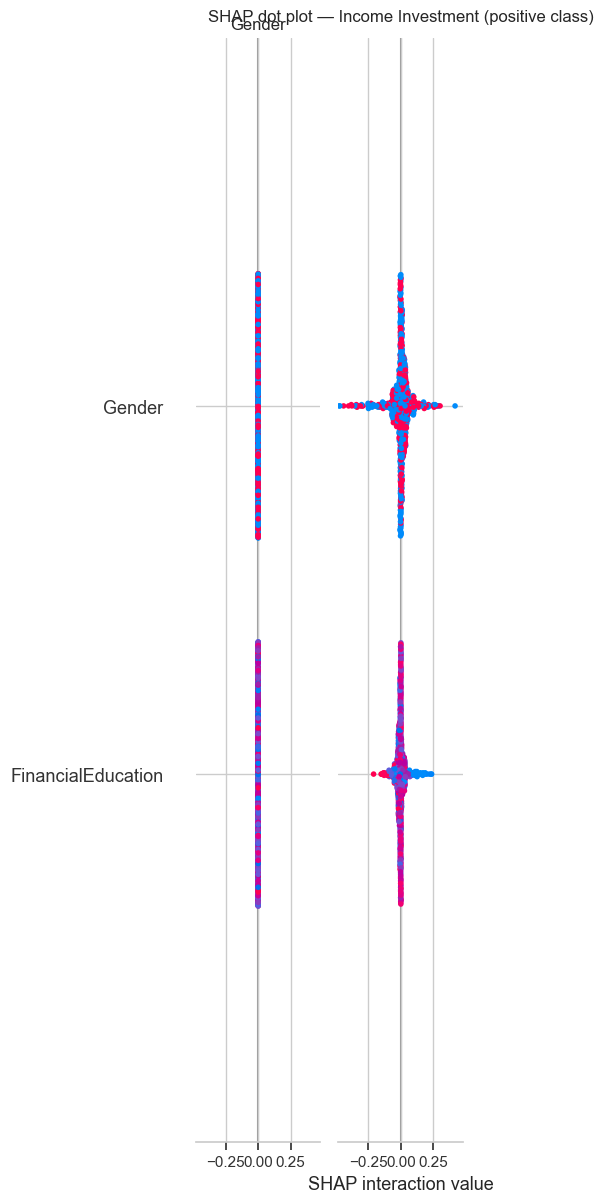

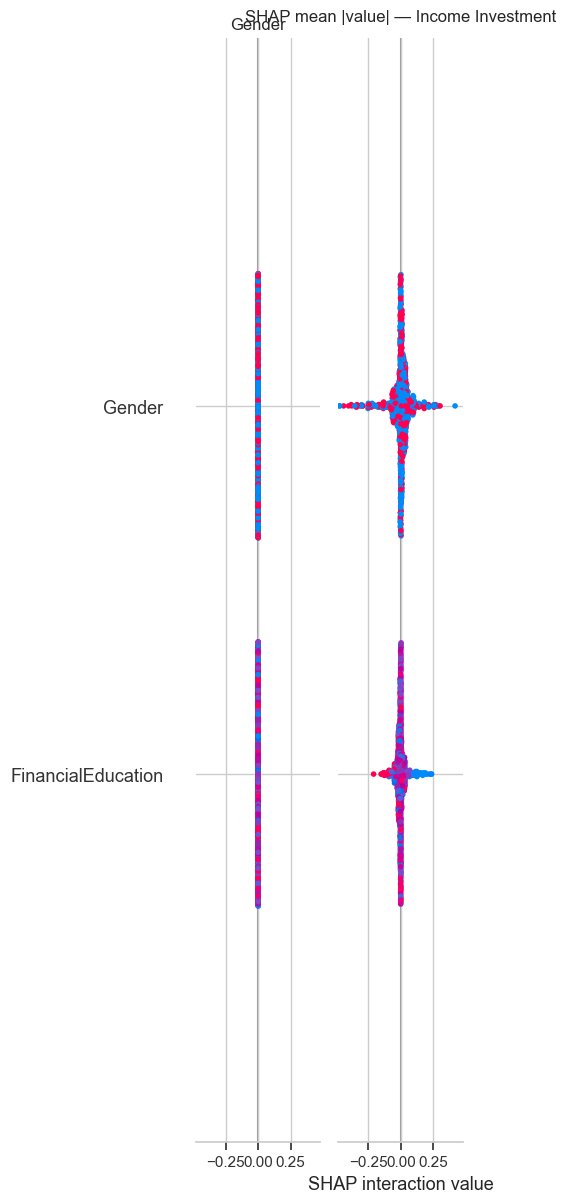


Local explanation for the first test client (Income Investment):


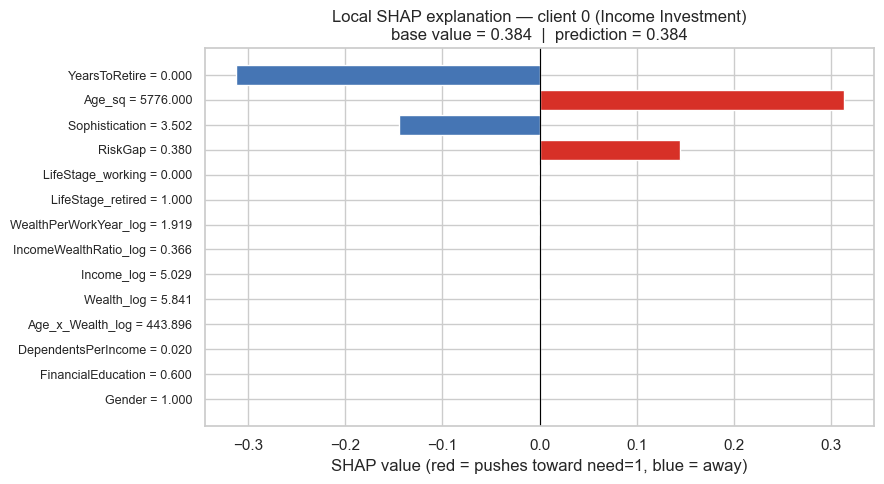


───────────────────────────────────────────────────────
  SHAP Summary — Accumulation Investment
───────────────────────────────────────────────────────


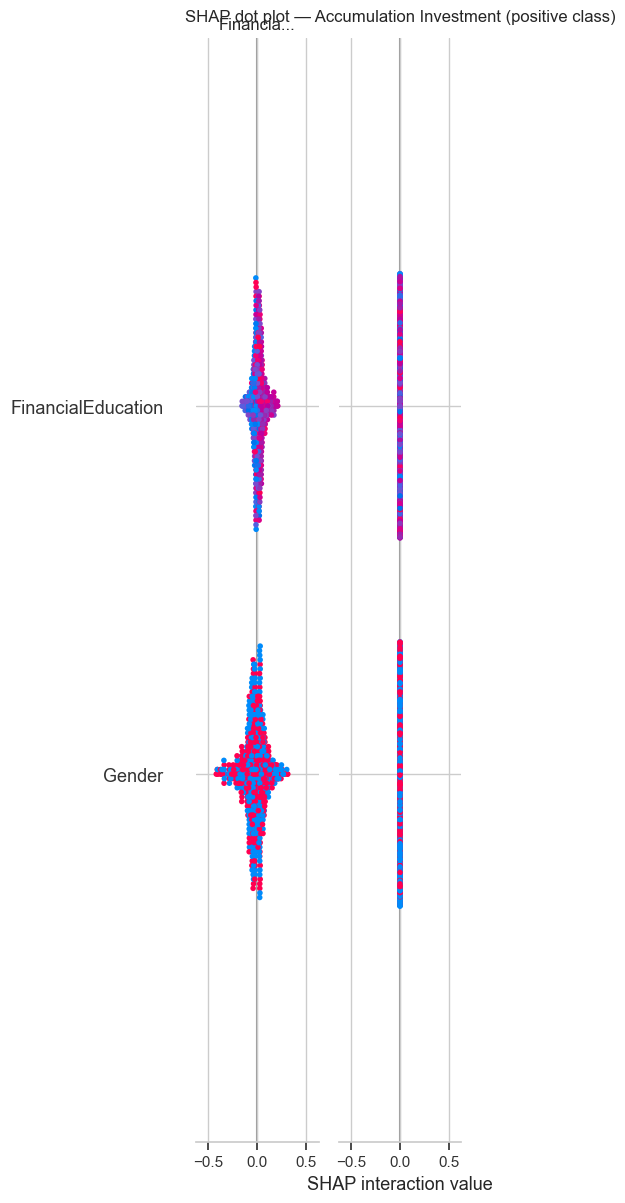

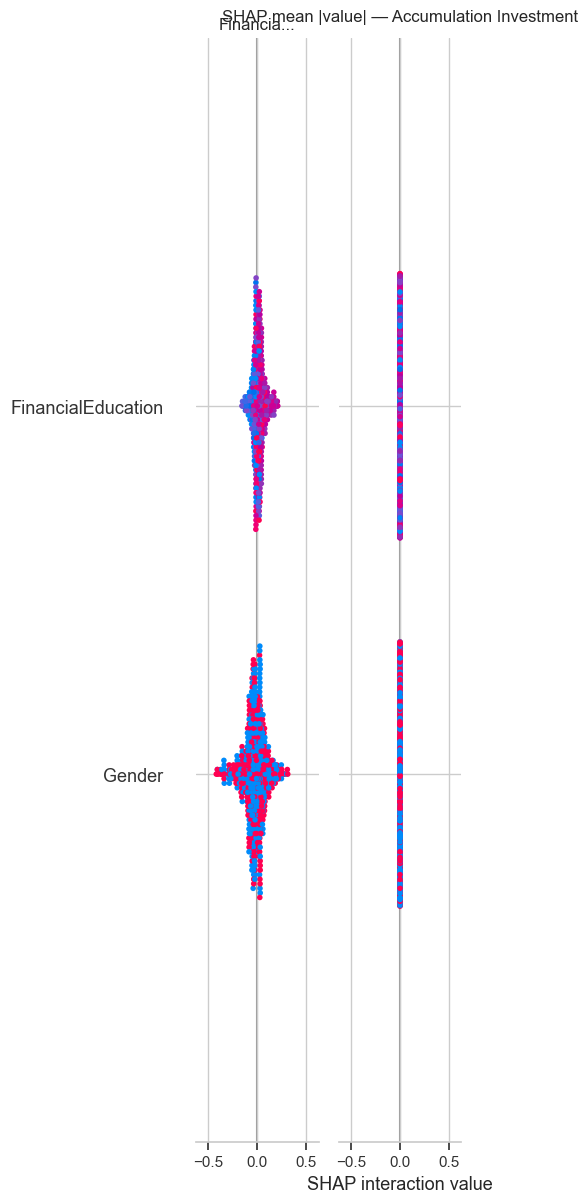


Local explanation for the first test client (Accumulation Investment):


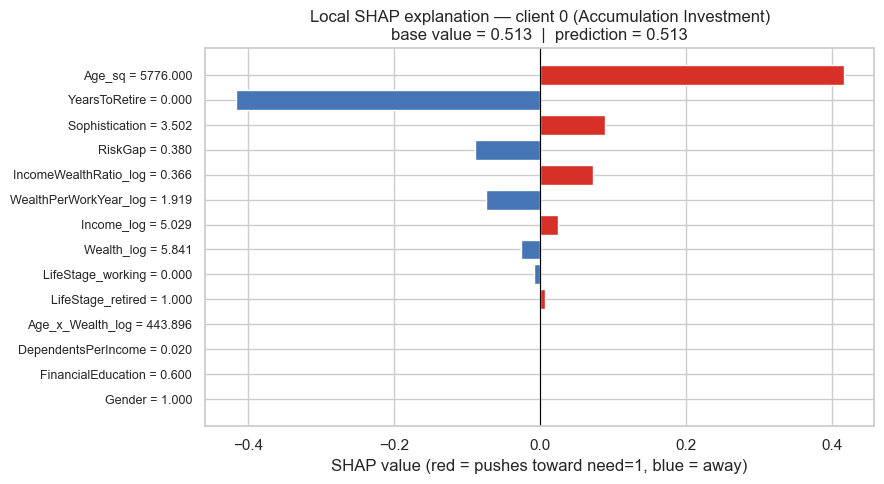

In [60]:
import shap

# We explain the tuned champion model for each target.
# TreeExplainer is exact for decision trees and requires no background sample.

# Retrieve the best tuned model and matching test split per target
champion_models = {}
champion_X_test = {}
for t_key, t_label, _ in TARGET_CONFIG:
    best_ap, best_f = -1, None
    for f_key, _, _ in FEATURE_CONFIG:
        ap = tuned_results[(t_key, f_key)]['test_metrics']['auc_pr']
        if ap > best_ap:
            best_ap, best_f = ap, f_key
    mdl = tuned_results[(t_key, best_f)].get('model') or \
          tuned_results[(t_key, best_f)]['fitted_model']
    _, X_te, _, _ = splits[(best_f, t_key)]
    champion_models[t_key]  = (mdl, best_f)
    champion_X_test[t_key]  = X_te
    print(f"{t_label}: champion feature set = {best_f}  (PR-AUC = {best_ap:.4f})")

# ── SHAP plots per target ────────────────────────────────────────────────────
for t_key, t_label, _ in TARGET_CONFIG:
    mdl, _ = champion_models[t_key]
    X_te   = champion_X_test[t_key]

    # TreeExplainer is exact for sklearn DecisionTreeClassifier
    explainer   = shap.TreeExplainer(mdl)
    shap_values = explainer.shap_values(X_te)

    # shap_values is a list [class_0, class_1] for binary classification;
    # index [1] corresponds to the positive class (need = 1)
    sv_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

    print(f"\n{'─'*55}")
    print(f"  SHAP Summary — {t_label}")
    print(f"{'─'*55}")

    # Dot plot: sign + magnitude per sample
    shap.summary_plot(
        sv_pos, X_te,
        feature_names=list(X_te.columns),
        plot_type='dot',
        max_display=15,
        show=False,
    )
    plt.title(f'SHAP dot plot — {t_label} (positive class)', pad=12)
    plt.tight_layout()
    plt.show()

    # Bar plot: mean |SHAP| ranking (cleaner for reports)
    shap.summary_plot(
        sv_pos, X_te,
        feature_names=list(X_te.columns),
        plot_type='bar',
        max_display=15,
        show=False,
    )
    plt.title(f'SHAP mean |value| — {t_label}', pad=12)
    plt.tight_layout()
    plt.show()

    # ── Local explanation: one example from the test set ─────────────────────
    # Shows how features pushed one specific prediction above/below the baseline.
    # Useful to show a regulator or client why they received a recommendation.
    #
    # SHAP >= v0.20 changed the force_plot API: expected_value must be a scalar
    # (not a list), and shap_values must be a 1-D array for a single sample.
    # For a binary DT, TreeExplainer returns expected_value as a list [ev0, ev1];
    # we take index [1] (positive class) to match sv_pos.
    print(f"\nLocal explanation for the first test client ({t_label}):")
    base_val = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else float(explainer.expected_value)
    )
    # Local explanation via a manual bar chart — more robust than force_plot
    # or waterfall_plot which have version-dependent shape requirements.
    # sv_pos shape may differ from X_te.shape[1] in some SHAP versions
    # (extra internal nodes), so we slice to the number of model features.
    n_feat      = len(X_te.columns)
    sv_client   = sv_pos[0].flatten()[:n_feat]  # slice to match features
    feat_names  = list(X_te.columns)
    feat_vals   = X_te.iloc[0, :].values

    # Sort by absolute SHAP value descending, keep top 15
    order       = np.argsort(np.abs(sv_client))[::-1][:15]
    sv_sorted   = sv_client[order]
    fn_sorted   = [f'{feat_names[i]} = {feat_vals[i]:.3f}' for i in order]

    fig_loc, ax_loc = plt.subplots(figsize=(9, 5))
    colors = ['#d73027' if v > 0 else '#4575b4' for v in sv_sorted]
    ax_loc.barh(range(len(sv_sorted)), sv_sorted[::-1],
               color=colors[::-1], edgecolor='white')
    ax_loc.set_yticks(range(len(sv_sorted)))
    ax_loc.set_yticklabels(fn_sorted[::-1], fontsize=9)
    ax_loc.axvline(0, color='black', lw=0.8)
    ax_loc.set_xlabel('SHAP value (red = pushes toward need=1, blue = away)')
    ax_loc.set_title(
        f'Local SHAP explanation — client 0 ({t_label})\n'
        f'base value = {base_val:.3f}  |  '
        f'prediction = {base_val + sv_client.sum():.3f}'
    )
    plt.tight_layout()
    plt.show()


---
## 13. Permutation Importance

SHAP is tree-specific. Permutation importance is **model-agnostic**: it
measures how much the test PR-AUC drops when a single feature is randomly
shuffled (breaking its relationship with the target). A large drop means the
feature is genuinely load-bearing; a near-zero or negative drop means it adds
little or no signal.

This is also directly comparable with the RF and NN notebooks, which run the
same analysis — making cross-model feature importance discussion easy.

We flag **dead-weight features**: those with a drop below a small threshold on
**both** targets. These are candidates for removal in a leaner feature set.


In [61]:
from sklearn.inspection import permutation_importance

# PR-AUC scorer: sklearn's permutation_importance accepts any callable
# scorer(estimator, X, y) -> float, so we wrap average_precision_score.
from sklearn.metrics import make_scorer, average_precision_score

# needs_proba=True tells sklearn to call predict_proba and pass the
# positive-class column [:,1] to average_precision_score.
# We avoid response_method= which was only added in sklearn 1.3.
pr_auc_scorer = make_scorer(
    average_precision_score,
    needs_proba=True,
)

perm_results = {}   # store per-target DataFrames for the dead-feature check

for t_key, t_label, _ in TARGET_CONFIG:
    mdl, best_f = champion_models[t_key]
    X_te        = champion_X_test[t_key]
    _, _, _, y_te = splits[(best_f, t_key)]

    print(f"Computing permutation importance for {t_label} (n_repeats=10)...")

    # n_repeats=10 gives stable mean/std; random_state for reproducibility
    perm = permutation_importance(
        mdl, X_te, y_te,
        scoring=pr_auc_scorer,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,   # use all available cores
    )

    perm_df = pd.DataFrame({
        'feature'  : list(X_te.columns),
        'mean_drop': perm.importances_mean,
        'std_drop' : perm.importances_std,
    }).sort_values('mean_drop', ascending=False).reset_index(drop=True)
    perm_results[t_key] = perm_df

    print(f"  Baseline PR-AUC: {tuned_results[(t_key, best_f)]['test_metrics']['auc_pr']:.4f}")

    # Horizontal bar chart: sorted by mean drop, error bars = std
    fig, ax = plt.subplots(figsize=(9, 6))
    df_plot  = perm_df.sort_values('mean_drop', ascending=True)
    colors   = ['#4c72b0' if t_key == 'accum' else '#dd8452'] * len(df_plot)
    ax.barh(df_plot['feature'], df_plot['mean_drop'],
            xerr=df_plot['std_drop'], color=colors,
            error_kw={'ecolor': 'black', 'alpha': 0.5})
    ax.axvline(0, color='black', lw=0.7, linestyle='--')
    ax.set_title(f'Permutation Importance — {t_label}\n'
                 f'(PR-AUC drop on test set, n_repeats=10)',
                 fontsize=11)
    ax.set_xlabel('Mean PR-AUC drop when feature is shuffled\n'
                  '(higher = more important; negative = noise)')
    plt.tight_layout()
    plt.show()

    print(f"\nTop 5 drivers for {t_label}:")
    print(perm_df.head(5).to_string(index=False))

# ── Dead-weight features: low drop on BOTH targets ────────────────────────
DEAD_THRESHOLD = 0.001  # < 0.1 pp PR-AUC drop is effectively noise
dead_features  = []

# Use the union of features across both champion sets for the joint check
all_features = set(perm_results['accum']['feature']) & \
               set(perm_results['income']['feature'])

for feat in all_features:
    d_acc = perm_results['accum'][
        perm_results['accum']['feature'] == feat]['mean_drop'].values
    d_inc = perm_results['income'][
        perm_results['income']['feature'] == feat]['mean_drop'].values
    if len(d_acc) and len(d_inc):
        if d_acc[0] < DEAD_THRESHOLD and d_inc[0] < DEAD_THRESHOLD:
            dead_features.append((feat, float(d_acc[0]), float(d_inc[0])))

print(f"\nFeatures with drop < {DEAD_THRESHOLD} on BOTH targets "
      f"(candidates for removal):")
if dead_features:
    for feat, da, di in sorted(dead_features, key=lambda x: x[1]):
        print(f"  {feat:30s}  Accum drop: {da:+.4f}   Income drop: {di:+.4f}")
else:
    print("  (none found — all features contribute some signal)")


Computing permutation importance for Income Investment (n_repeats=10)...


TypeError: average_precision_score() got an unexpected keyword argument 'needs_proba'

---
## 14. Conceptual Note: Label Noise and Selection Bias

`IncomeInvestment` and `AccumulationInvestment` are **proxy labels derived
from observed advisor behaviour** (revealed-preference scheme), not direct
measurements of client need. Two practical consequences:

1. **Label noise.** The model clones the advisor process. If an advisor
   recommended the wrong product (conflict of interest, misjudgement), that
   error is baked into the training labels. This is why the professor suggests
   *expert-picking* — filtering out advisors with suspiciously biased sales
   patterns — before constructing the labels.

2. **Selection bias / Recall underestimation.** Clients *without* a matching
   product are labelled `y = 0`, but some of them may genuinely have the need
   (it just was never acted on). This biases Recall downward; a model that
   scores high Recall likely found real needs that were missed, not errors.
   In production, labels should be periodically re-evaluated against
   post-recommendation acceptance data.

3. **MiFID/IDD implication.** Under the Retail Investment Strategy (RIS),
   recommendations must serve the client's *best interest*. A model trained
   on advisor behaviour implicitly inherits any systemic mis-selling bias
   present in the historical data. Regular audits of the recommendation
   distribution (e.g., do high-fee products get over-recommended?) are
   necessary before deploying such a system in production.


---
## 15. Next Best Action — Personalized Product Recommendation

### Overview

Once client needs have been predicted, the second step of the pipeline is
matching each client with the most suitable investment product.
The recommendation follows a **four-factor scoring rule**:

```
Score = P(need | calibrated) × Suitability × Utility × ComplianceMask
```

- **P(need)**: calibrated probability from the champion DT model.
  We use Platt scaling (logistic calibration on the validation set) to
  convert raw DT probabilities into well-calibrated scores. DTs are
  notoriously overconfident (leaf probabilities cluster near 0/1), so
  calibration is important before using these as real-valued propensity scores.
- **Suitability**: Gaussian decay around the client's `RiskPropensity`.
  A product at exactly the client's risk level gets score 1; products
  further away get exponentially penalised.
- **Utility**: mock business value weight (uniform in [0.6, 1.0]).
  In production this would reflect product margin or strategic priority.
- **ComplianceMask (hard gate)**: zero score if product risk > client risk + 0.05
  (MiFID suitability rule) OR if the client already owns that product.

We generate a **Top-3 recommendation** for every client in the full dataset
(not just the test split), then analyse coverage and catalogue gaps.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# ── Step 1: Platt calibration fitted on the VALIDATION portion of train ──────
# We carve out a calibration set from X_base_train (20% of train) so the
# calibration fit never sees the held-out test set.
# Note: we use base features here because the champion DT for each target may
# have won on either base or engineered — calibration acts on raw probabilities
# so it is feature-set agnostic.

from sklearn.model_selection import train_test_split as tts

def fit_calibrator(mdl, X_tr, y_tr, name):
    """
    Fit a Platt scaler (logistic regression on raw DT probabilities) using
    a hold-out calibration split carved from the training data.

    Falls back to identity if calibration worsens the Brier score on the
    calibration split — avoids hurting well-calibrated models.

    Parameters
    ----------
    mdl  : fitted DecisionTreeClassifier
    X_tr, y_tr : full training features and target
    name : label for printed output

    Returns
    -------
    calibrate : callable  p_raw (1-D array) -> p_calibrated (1-D array)
    kept      : bool      True if calibration was applied
    """
    # Split train into a smaller fit set and a calibration hold-out
    X_fit, X_cal, y_fit, y_cal = tts(
        X_tr, y_tr, test_size=0.20,
        stratify=y_tr, random_state=RANDOM_STATE
    )

    # Refit the model on the reduced training set to get uncalibrated probs
    mdl_cal = mdl.__class__(**mdl.get_params())
    mdl_cal.fit(X_fit, y_fit)
    p_raw = mdl_cal.predict_proba(X_cal)[:, 1]

    # Platt scaler: logistic regression on the raw probability scalar
    lr = LogisticRegression(C=1.0, solver='liblinear')
    lr.fit(p_raw.reshape(-1, 1), y_cal)

    calibrate     = lambda p: lr.predict_proba(p.reshape(-1, 1))[:, 1]
    brier_raw = brier_score_loss(y_cal, p_raw)
    brier_cal = brier_score_loss(y_cal, calibrate(p_raw))

    if brier_cal < brier_raw:
        print(f"  {name}: calibration KEPT  "
              f"(Brier {brier_raw:.4f} → {brier_cal:.4f})")
        return calibrate, True
    else:
        print(f"  {name}: calibration SKIPPED "
              f"(Brier {brier_raw:.4f} → {brier_cal:.4f}, would hurt)")
        return (lambda p: p), False


print("Fitting Platt calibrators for each target champion model:")

# Retrieve champion models fitted on the FULL train set (from Section 12)
# champion_models[t_key] = (fitted_model, best_f_key)
mdl_acc, f_acc = champion_models['accum']
mdl_inc, f_inc = champion_models['income']

X_tr_acc, _, y_tr_acc, _ = splits[(f_acc, 'accum')]
X_tr_inc, _, y_tr_inc, _ = splits[(f_inc, 'income')]

cal_acc, acc_kept = fit_calibrator(mdl_acc, X_tr_acc, y_tr_acc, 'Accumulation')
cal_inc, inc_kept = fit_calibrator(mdl_inc, X_tr_inc, y_tr_inc, 'Income      ')

# ── Step 2: Generate calibrated probabilities for ALL clients ─────────────
# We use the champion feature set for each target; models were fitted on
# the train split, so applying them to the full dataset is leakage-free
# on the FEATURE side. Probabilities on train rows are optimistic, but the
# NBA is a deployment-time tool — in production it would run on new clients.

X_full_acc, X_full_inc = prepare_features(needs_df)
if f_acc == 'engineered':
    X_full_acc = X_full_inc  # prepare_features returns (base, eng); reuse

# Re-build full feature matrices matching the winning feature set
X_full_base, X_full_eng = prepare_features(needs_df)
X_for_acc = X_full_eng if f_acc == 'engineered' else X_full_base
X_for_inc = X_full_eng if f_inc == 'engineered' else X_full_base

# Raw → calibrated probabilities for every client
p_acc_all = cal_acc(mdl_acc.predict_proba(X_for_acc)[:, 1])
p_inc_all = cal_inc(mdl_inc.predict_proba(X_for_inc)[:, 1])

print(f"\nPropensity statistics (calibrated, all clients):")
print(f"  Accumulation — mean: {p_acc_all.mean():.3f}  "
      f"std: {p_acc_all.std():.3f}")
print(f"  Income       — mean: {p_inc_all.mean():.3f}  "
      f"std: {p_inc_all.std():.3f}")

# Histogram of calibrated propensities — sanity check for calibration quality
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, label, color in [
    (axes[0], p_acc_all, 'Accumulation', '#4c72b0'),
    (axes[1], p_inc_all, 'Income',       '#dd8452'),
]:
    ax.hist(probs, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0.5, color='red', linestyle='--', lw=1.5, label='threshold=0.5')
    ax.set_title(f'Calibrated P(need) — {label}')
    ax.set_xlabel('Calibrated probability')
    ax.set_ylabel('Number of clients')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of calibrated need propensities (all clients)',
             fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Step 3: Scoring and recommendation loop ──────────────────────────────

# Mock 'business utility' per product — in production this would come from
# a product margin table. We weight it gently so that need propensity still
# dominates, preserving ethical and regulatory alignment.
np.random.seed(0)
products_df['Utility'] = np.random.uniform(0.6, 1.0, size=len(products_df))

# Mock ownership lookup: maps client_id -> set of product IDs already owned.
# In production this is a join against the holdings table.
# Here we leave it empty (no prior ownership data) — easy to extend.
owned_lookup = {}   # dict: int -> set(int)

client_risks = needs_df['RiskPropensity'].values


def compute_score(p_need, client_risk, product_row, owned_set):
    """
    Compute a compliance-aware recommendation score for one client-product pair.

    Formula
    -------
    Score = P(need) x Suitability(risk_gap) x Utility x ComplianceMask

    ComplianceMask (hard gates — both must pass):
      1. Product risk <= client risk + 0.05  (MiFID suitability rule)
      2. Client does not already own the product

    Suitability: Gaussian decay exp(-3 * risk_gap^2) where
      risk_gap = client_risk - product_risk
    This peaks at 1 when product risk == client risk and decays as the
    product becomes either too risky OR too conservative. The 0.05 hard
    tolerance prevents a tiny breach from zeroing an otherwise ideal match.

    Parameters
    ----------
    p_need       : float  calibrated probability of the relevant need
    client_risk  : float  RiskPropensity in [0, 1]
    product_row  : pd.Series  one row from products_df
    owned_set    : set   product IDs already owned by this client

    Returns
    -------
    float  score in [0, 1], or 0.0 if either compliance gate fails
    """
    # --- Hard compliance gates (MiFID rule) ---
    if product_row['Risk'] > client_risk + 0.05:
        return 0.0   # product too risky for this client — block unconditionally
    if product_row['IDProduct'] in owned_set:
        return 0.0   # client already owns this product — skip

    # --- Suitability: Gaussian peak at client's own risk level ---
    risk_gap    = client_risk - product_row['Risk']
    suitability = np.exp(-3.0 * risk_gap ** 2)

    return p_need * suitability * product_row['Utility']


# ── Recommendation loop: Top-3 per client ────────────────────────────────────
recommendations = []

for i in range(len(needs_df)):
    c_id   = i + 1          # 1-indexed client ID
    owned  = owned_lookup.get(c_id, set())
    scores = []

    for _, prod in products_df.iterrows():
        # Select the right propensity score based on product type
        # Type=1 -> Accumulation product, use p_acc_all
        # Type=0 -> Income product,       use p_inc_all
        p_need = p_acc_all[i] if prod['Type'] == 1 else p_inc_all[i]
        s      = compute_score(p_need, client_risks[i], prod, owned)
        if s > 0:
            scores.append((prod['IDProduct'], s))

    # Sort by score descending; pad with (None, 0.0) to always get 3 entries
    scores.sort(key=lambda x: x[1], reverse=True)
    scores += [(None, 0.0)] * (3 - len(scores))

    recommendations.append({
        'ClientID': c_id,
        'Rec_1':    scores[0][0], 'Score_1': round(scores[0][1], 4),
        'Rec_2':    scores[1][0], 'Score_2': round(scores[1][1], 4),
        'Rec_3':    scores[2][0], 'Score_3': round(scores[2][1], 4),
    })

recs_df = pd.DataFrame(recommendations)

print("Top-3 compliant recommendations (first 10 clients):")
display(recs_df.head(10))
print(f"\nClients with ≥1 eligible recommendation: "
      f"{recs_df['Rec_1'].notna().sum()} / {len(recs_df)}")
print(f"\nProduct frequency as first recommendation (Rec_1):")
print(recs_df['Rec_1'].value_counts().to_string())


In [ ]:
# ── Step 4: Visualise recommendation results ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 4a. Product recommendation frequency (Rec_1 only) ---
rec_counts = recs_df['Rec_1'].value_counts().sort_index().dropna()
axes[0].bar(rec_counts.index.astype(str), rec_counts.values,
            color='#4c72b0', edgecolor='white')
axes[0].set_title('Product frequency — Rec_1\n(most recommended product per client)')
axes[0].set_xlabel('Product ID')
axes[0].set_ylabel('Number of clients')
axes[0].tick_params(axis='x', rotation=45)

# --- 4b. Suitability scatter: client risk vs recommended product risk ---
# Filter to clients with at least one recommendation
rec_valid = recs_df[recs_df['Rec_1'].notna()].copy()
rec_valid = rec_valid.merge(
    products_df[['IDProduct', 'Risk']].rename(columns={'Risk': 'ProdRisk'}),
    left_on='Rec_1', right_on='IDProduct', how='left'
)
rec_valid['ClientRisk'] = client_risks[rec_valid['ClientID'].values - 1]

axes[1].scatter(rec_valid['ClientRisk'], rec_valid['ProdRisk'],
                alpha=0.4, s=18, color='#4c72b0')
max_val = max(rec_valid['ClientRisk'].max(), rec_valid['ProdRisk'].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect match')
axes[1].set_title('Suitability check\nClient risk vs product risk (Rec_1)')
axes[1].set_xlabel('Client RiskPropensity')
axes[1].set_ylabel('Recommended product risk')
axes[1].legend(fontsize=9)

# --- 4c. Risk propensity distribution of recommended clients ---
axes[2].hist(rec_valid['ClientRisk'], bins=20,
             color='#dd8452', alpha=0.8, edgecolor='white')
axes[2].set_title('Risk propensity distribution\n(clients who received Rec_1)')
axes[2].set_xlabel('RiskPropensity')
axes[2].set_ylabel('Count')

plt.suptitle('Recommendation Analysis — Decision Tree NBA', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Step 5: Catalogue gap decomposition ──────────────────────────────────────
# Clients without any recommendation fall into two very different buckets:
#   (a) No need predicted — the model correctly said 'no need'; silence is right.
#   (b) Catalogue gap    — need WAS predicted above threshold, but no compliant
#       product exists for this client's risk profile.
#       This is a PRODUCT LINE GAP, not a model failure — actionable business
#       insight for the product development team.

CAL_THRESHOLD = 0.5   # probability threshold to consider a need 'predicted'

need_predicted = (p_acc_all >= CAL_THRESHOLD) | (p_inc_all >= CAL_THRESHOLD)
has_any_rec    = recs_df['Rec_1'].notna().values

no_need       = (~need_predicted) & (~has_any_rec)
catalogue_gap =  need_predicted   & (~has_any_rec)
covered       =  has_any_rec

refined = pd.DataFrame({
    'Segment': [
        'No need predicted (correct silence)',
        'Catalogue gap (need predicted, no compliant product)',
        'At least one recommendation emitted',
    ],
    'Clients': [int(no_need.sum()),
                int(catalogue_gap.sum()),
                int(covered.sum())],
    'Pct (%)': [round(no_need.mean() * 100, 1),
                round(catalogue_gap.mean() * 100, 1),
                round(covered.mean() * 100, 1)],
})

print("\n=== REFINED COVERAGE: why are some clients not covered? ===")
display(refined)

# Per-head partial gap breakdown
acc_gap = (p_acc_all >= CAL_THRESHOLD) & (~has_any_rec)
inc_gap = (p_inc_all >= CAL_THRESHOLD) & (~has_any_rec)
print(f"\nPartial catalogue gaps (per need head):")
print(f"  Accumulation need predicted but NO compatible product : "
      f"{int(acc_gap.sum())}")
print(f"  Income        need predicted but NO compatible product : "
      f"{int(inc_gap.sum())}")
print("\nBusiness insight: catalogue gap clients are ACTIONABLE — the model")
print("correctly identified a need, but no product in the current catalogue")
print("fits their risk tolerance. This is a product line opportunity, not")
print("a model limitation.")
